## Here is an example

In [1]:
import json
import openai
import os 

def load_api_key(secrets_file="/home/kaichiht/openai.json"):
    with open(secrets_file) as f:
        secrets = json.load(f)
    return secrets["OPENAI_API_KEY"]

# Set secret API key
# Typically, we'd use an environment variable (e.g., echo "export OPENAI_API_KEY='yourkey'" >> ~/.zshrc)
# However, using "internalConsole" in launch.json requires setting it in the code for compatibility with Hebrew
api_key = load_api_key()
openai.api_key = api_key

%reload_ext jupyter_ai

os.environ["OPENAI_API_KEY"]=openai.api_key

ModuleNotFoundError: No module named 'openai'

In [2]:
%%ai chatgpt
how to import h5py library 

UsageError: Cell magic `%%ai` not found.


In [118]:
import h5py
PR=50
with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec_0_600hPa_sum.dat"
) as f:
        prec = f["prec"][:, :]

In [4]:
# This program is to reconstruct the signal of the signal of Kelvin waves
# Basic Settring 
# # import package
import sys
import h5py
import numpy as np

# from cartopy import crs as ccrs
# from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter 

from matplotlib import colors as cm
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import sys
import os
import importlib.util

# Define the path to the Theory.py file directly
theory_file_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PowerSpec_Dycore/Package/Theory.py"

# Load the module from the file path
spec = importlib.util.spec_from_file_location("Theory", theory_file_path)
th = importlib.util.module_from_spec(spec)
sys.modules["Theory"] = th
spec.loader.exec_module(th)

level_index = 5

# level_index = 18

# sys.path.append("/home/b11209013/Package/")
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PowerSpec_Dycore/Package/")
import Theory as th

# Verify that it's the correct module
print(th)
# ================== #
# functions
# # plot setting
def plot_setting():
    plt.rcParams["axes.titlesize"] = 14
    plt.rcParams["axes.labelsize"] = 12
    plt.rcParams["xtick.labelsize"] = 10
    plt.rcParams["ytick.labelsize"] = 10
    plt.rcParams["font.family"] = "serif"

# ================== #
# main function
def main(PR):
    # load data
    path:str = f"/home/b11209013/2024_Research/PowerSpec_Dycore/data/pr{PR}/"

    # # range latitude
    lat = np.linspace(-90, 90, 64)
    
    lat_cond = np.where((lat>=-15)&(lat<=15))[0]
    # lat_cond = np.where((lat>=-45)&(lat<=45))[0]
    
    lat = lat[lat_cond]
    print(lat)
    # prec data
    # with h5py.File(path+"prec_pr50.dat") as f:
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec_0_600hPa_sum.dat"
) as f:
        prec = f["prec"][:, lat_cond]
    prec -= prec.mean(axis=0)
    prec *= 86400
    
    
    # u-wind
    # with h5py.File(path+"u_pr50.dat") as f:
        # u = f["u"][:, 5, lat_cond]

    # u -= u.mean(axis=0)

    # pressure
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/p/PR{PR}_500_20000day_6hourly_p.dat") as f:
        p = f["p"][:, level_index, lat_cond]
    p -= p.mean(axis=0)

    # z
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/z/PR{PR}_500_20000day_6hourly_z.dat") as f:
        z = f["z"][:, level_index, lat_cond]
    z -= z.mean(axis=0)





    # ================= #
    # Reconstruct Kelvin waves
    # # FFT
    # precpitation
    prec_fft = np.array([
        np.fft.fftshift(np.fft.fft2(prec[:, i, :]))[:, ::-1]
        for i in range(len(lat_cond))
        ])
    # (lat, time, lon)

    p_fft = np.array([
        np.fft.fftshift(np.fft.fft2(p[:, i, :]))[:, ::-1]
        for i in range(len(lat_cond))
        ])

    z_fft = np.array([
        np.fft.fftshift(np.fft.fft2(z[:, i, :]))[:, ::-1]
        for i in range(len(lat_cond))
        ])



    # # # u-wind
    # u_fft = np.array([
    #     np.fft.fftshift(np.fft.fft2(u[:, i, :]))[:, ::-1]
    #     for i in range(len(lat_cond))
    #     ])

    # # # # v-wind
    # v_fft = np.array([
    #     np.fft.fftshift(np.fft.fft2(v[:, i, :]))[:, ::-1]
    #     for i in range(len(lat_cond))
    #     ])


    # # dimension for bandpass filter
    wn = np.linspace(-64, 64, 128)
    fr = np.linspace(-2, 2, 78000)

    wnm, frm = np.meshgrid(wn, fr)
    kel_curves = lambda k, ed: (86400/(2*np.pi*6.371e6))*np.sqrt(9.81*ed)*k

    ed8 = kel_curves(wnm, 8)
    ed25 = kel_curves(wnm, 25)
    ed90 = kel_curves(wnm, 90)

    # cond = np.logical_or.reduce([
    #     wnm <= 1, wnm >= 6,
    #     # frm > -0.05, frm < -0.5,     
    #     frm > -0.01, frm < -0.15,     
        
    #     # frm >= -ed8.Kelvin(), frm <= -ed90.Kelvin()
    #     frm >= -ed8.Kelvin(), frm <= -ed25.Kelvin()
        
    #     ])
    cond = (
    # (wnm >= 0) & (wnm <= 3) &
    (wnm >= 0) & (wnm <= 3) &
    (frm >= 0.) & (frm <= 0.12) &        
    # (frm <= ed90) & (frm >= ed8)
    (frm <= ed25) & (frm >= ed8)
        
        
        
)
    
    # # bandpass filter and inverse FFT
    # # # IFFT
    prec_ifft = []
    # u_ifft = []
    # v_ifft = []
    p_ifft = []
    z_ifft = []
    
    

    # for i in range(len(lat_cond)):
    #     prec_filted = np.where(cond == True, 0, prec_fft[i]*2)
    #     prec_ifft.append(np.fft.ifft2(np.fft.ifftshift(prec_filted)))


    #     # u_filted = np.where(cond == True, 0, u_fft[i]*2)
    #     # u_ifft.append(np.fft.ifft2(np.fft.ifftshift(u_filted)))

    #     # v_filted = np.where(cond == True, 0, v_fft[i]*2)
    #     # v_ifft.append(np.fft.ifft2(np.fft.ifftshift(v_filted)))

    #     p_filted = np.where(cond == True, 0, p_fft[i]*2)
    #     p_ifft.append(np.fft.ifft2(np.fft.ifftshift(p_filted)))

    #     z_filted = np.where(cond == True, 0, z_fft[i]*2)
    #     z_ifft.append(np.fft.ifft2(np.fft.ifftshift(z_filted)))


        # Applying the bandpass filter and inverse FFT
    def apply_ifft_with_filter(data_fft, cond):
        return np.stack([
            np.fft.ifft2(np.fft.ifftshift(np.where(cond, data_fft[i] * 2, 0)[:,::-1])).real
            for i in range(data_fft.shape[0])
        ], axis=1)

    # Reconstructing signals
    prec_recon = apply_ifft_with_filter(prec_fft, cond)
    p_recon = apply_ifft_with_filter(p_fft, cond)
    z_recon = apply_ifft_with_filter(z_fft, cond)
    

    

    return prec_recon, p_recon, z_recon
# ===================== #
# execution section
if __name__ == "__main__":
    PR = 0
    # prec_recon, p_recon = main(PR)
    prec_recon, p_recon, z_recon = main(PR)
    
    print("done")

#########################################################

<module 'Theory' from '/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PowerSpec_Dycore/Package/Theory.py'>
[-12.85714286 -10.          -7.14285714  -4.28571429  -1.42857143
   1.42857143   4.28571429   7.14285714  10.          12.85714286]


KeyboardInterrupt: 

In [12]:
# load data
print(PR)
lat         = np.linspace(-90, 90, 64)
lat_cond    = np.where((lat>=-15)&(lat<=15))[0]
with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/z/PR{PR}_500_20000day_6hourly_z.dat") as f:
    z = f["z"][:, level_index, :]
z -= z.mean(axis=0)

with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec_0_600hPa_sum.dat"
) as f:
        prec = f["prec"][:, :]
prec -= prec.mean(axis=0)
prec *= 86400

with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/p/PR{PR}_500_20000day_6hourly_p.dat") as f:
        p = f["p"][:, level_index, :]
p -= p.mean(axis=0)


# plt.figure()
# plt.contourf(tmp)

50


In [495]:
level_index

5

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def fft_filtering(data,dim,wave_numbers):
    n_points = data.shape[dim]
    n_dim    = data.ndim
    print(n_points)
    print(n_dim)
    # move the dimension of interest to the first place 
    order             = ['i','j','k','l','m','n']
    old_dim  = ""
    for i in range(dim+1):
        old_dim         += str(order[i])
    print(old_dim)

    order.insert(0, order.pop(dim))
    new_dim  = ""
    for i in range(dim+1):
        new_dim         += str(order[i])
    print(new_dim)
    # Perform FFT
    fft_values     = np.fft.fft(data,axis=dim)
    frequencies    = np.fft.fftfreq(n_points)

    # swapped data order 
    fft_values     = np.einsum(old_dim+'->'+new_dim, fft_values)

    # find which wave number should be kept
    posi           = np.where(np.isin(np.abs(frequencies*n_points),wave_numbers))[0]

    # filtering data
    filtered_data  = np.zeros_like(fft_values)
    filtered_data[posi,:] = fft_values[posi,:]
    
    # swapped back to original order 
    filtered_data  = np.einsum(new_dim+'->'+old_dim, filtered_data)
    filtered_data  = np.fft.ifft(filtered_data,axis=dim).real
    
  
    return filtered_data




In [679]:
%%ai chatgpt
how to tell if a variable exist in python

To check if a variable exists in Python, you can use the `globals()` function to access the global namespace and then use the `in` keyword to check if the variable is present. Here is an example code snippet:

```python
variable_name = 'example_variable'

if 'variable_name' in globals():
    print('Variable exists')
else:
    print('Variable does not exist')
```

Replace `'example_variable'` with the name of the variable you want to check for existence. This code will output whether the variable exists or not in the global namespace.

In [6]:
if 'z_wn1' in globals():
    print('Variable exists')
else:
    print('Variable does not exist')

Variable does not exist


128
3
ijk
kij
128
3
ijk
kij
128
3
ijk
kij


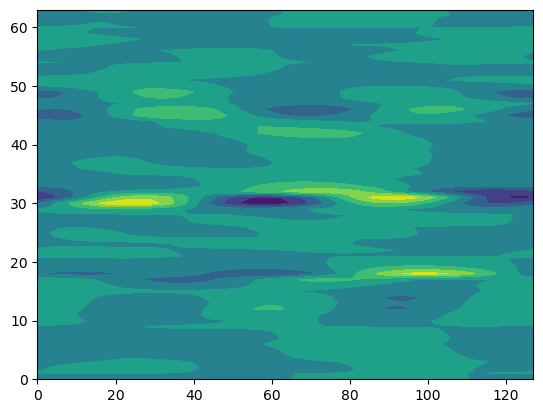

In [7]:
if 'z_wn1' in globals():
    del z_wn1
if 'prec_wn1' in globals():
    del prec_wn1
if 'vor_wn1' in globals():
    del vor_wn1

prec_wn1   = fft_filtering(prec,dim=2,wave_numbers=[1,2])
z_wn1_2      = fft_filtering(z,dim=2,wave_numbers=[1,2]) # wave number 1~2 for shading
# z_wn1      = fft_filtering(z,dim=2,wave_numbers=[5,6])
# z_wn1      = fft_filtering(z,dim=2,wave_numbers=[5,6])
z_wn5_6      = fft_filtering(z,dim=2,wave_numbers=[5,6]) # wave number 5~6 for contour

plt.figure()
plt.contourf(prec_wn1[500,:,:])


(78000, 64, 128)


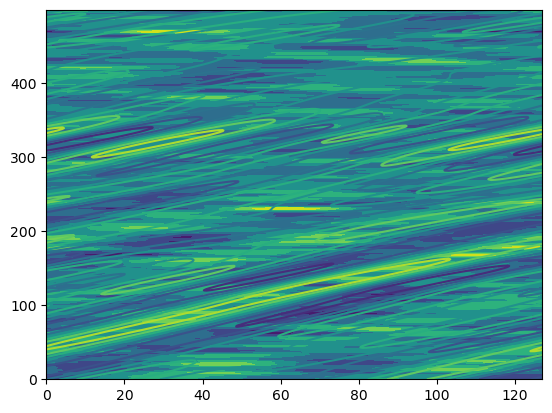

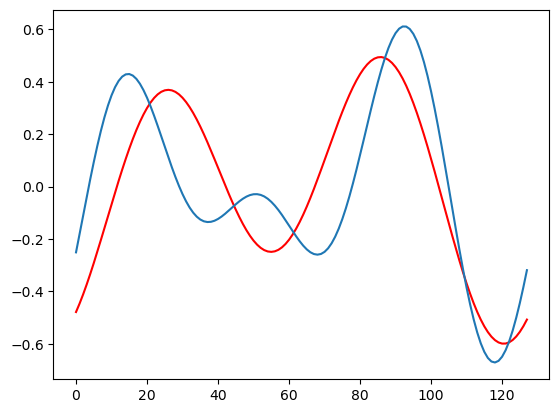

In [8]:
plt.figure()
plt.contourf(prec_wn1[500:1000,lat_cond,:].mean(axis=1))
plt.contour(prec_recon[500:1000,:,:].mean(axis=1))

plt.figure()
plt.plot(prec_wn1[500,lat_cond,:].mean(axis=0),'r')
plt.plot(prec_recon[500,:,:].mean(axis=0))
print(z_wn1_2.shape)

In [759]:
%%ai chatgpt 
how to deepcopy a array in python

```python
import copy

# Original array
original_arr = [1, 2, 3, 4, 5]

# Deepcopy of the array
deepcopy_arr = copy.deepcopy(original_arr)

print(deepcopy_arr)
```

In [7]:
# import copy
# # rolling the data and make composite all over again 
# variables_to_delete = ['tmp','tmp_z','tmp_prec_wn1','tmp_z_wn1', 'tmp_vor_wn1']

# for variable in variables_to_delete:
#     if variable in globals():
#         del globals()[variable]
    
# tmp                = prec_recon.mean(axis=1)[:,:]
# tmp_z              = copy.deepcopy(z[:,:,:].reshape([78000*64,128]))
# tmp_prec_wn1       = copy.deepcopy(prec_wn1[:,:,:].reshape([78000*64,128]))
# tmp_z_wn1_2          = copy.deepcopy(z_wn1_2[:,:,:].reshape([78000*64,128]))
# tmp_z_wn5_6          = copy.deepcopy(z_wn5_6[:,:,:].reshape([78000*64,128]))

# # tmp_vor_wn1        = copy.deepcopy(vor_wn1[:,:,:].reshape([78000*64,128]))

# posi_time,posi_x = np.where(tmp == np.max(tmp,axis=1)[:,np.newaxis])

# lag = 5*4 
# for i in range(tmp.shape[0]):
#     if i >= (78000-lag):
#         pass
#     else:
#         tmp[(i+lag),:]                        = np.roll(tmp[(i+lag),:], 64-posi_x[i])
#         tmp_z[(i+lag)*64:((i+lag)+1)*64,:]          = np.roll(tmp_z[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
#         tmp_prec_wn1[(i+lag)*64:((i+lag)+1)*64,:]   = np.roll(tmp_prec_wn1[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
#         tmp_z_wn1_2[(i+lag)*64:((i+lag)+1)*64,:]      = np.roll(tmp_z_wn1_2[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])

#         tmp_z_wn5_6[(i+lag)*64:((i+lag)+1)*64,:]      = np.roll(tmp_z_wn5_6[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])

        
#         # tmp_vor_wn1[(i+lag)*64:((i+lag)+1)*64,:]      = np.roll(tmp_vor_wn1[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
        



In [927]:
# Select time index
def Cal_EOF_PC_for_barotropic(input_data):
    from EOF import EOF
    # input : (time, y)
    
    # Perform latitude weighting
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[1]))))

    # Initialize an EOF instance with weighted input data
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    print("n_component:", n_component)
    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="1D")
    
    # Compute EOFs and PCs
    eof_instance.get()
    
    # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]

    # Normalize PCs and EOFs
    PC1_norm, PC2_norm = PC1 / PC1.std(), PC2 / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
    return EOF1_norm, PC1_norm, EOF2_norm, PC2_norm
    
file_path = f"/data92/PeterChang/1014_preprocessing/PR{PR}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"        
with h5py.File(file_path, 'r') as U_file:
    print(U_file.keys())
    u = U_file["u"][:, :]  # Barotropic u
# u_daily = np.mean(u.reshape(-1,4,64), axis=1)
# print(u_daily.shape)

EOF1, PC1, EOF2, PC2 = Cal_EOF_PC_for_barotropic(u[:,32:])

time_idx_positive = np.where(PC1 > 1 * PC1.std())[0]
time_idx_negative = np.where(PC1 < -1 * PC1.std())[0]
print(time_idx_positive.shape)

<KeysViewHDF5 ['u']>
n_component: 32
(15016,)


In [68]:
import copy
# rolling the data and make composite all over again 
variables_to_delete = ['tmp','tmp_z','tmp_prec_wn1','tmp_z_wn1']

for variable in variables_to_delete:
    if variable in globals():
        del globals()[variable]


lag_5_20   = range(5*4, 10*4+1)
# lag_90_100 = range(90*4, 100*4)

length_5_20   = len(lag_5_20)
# length_90_100 = len(lag_90_100)


tmp              = prec_recon.mean(axis=1)[:,:]
tmp_z            = copy.deepcopy(z[:,:,:].reshape([78000*64,128]))
tmp_prec_wn1     = copy.deepcopy(prec_wn1[:,:,:].reshape([78000*64,128]))
tmp_z_wn5_6        = copy.deepcopy(z_wn5_6[:,:,:].reshape([78000*64,128]))
tmp_z_wn1_2        = copy.deepcopy(z_wn1_2[:,:,:].reshape([78000*64,128]))

tmp_lag_5_20              = np.zeros([78000,128])
tmp_z_lag_5_20            = np.zeros([78000*64,128])
tmp_prec_wn1_lag_5_20     = np.zeros([78000*64,128])
tmp_z_wn5_6_lag_5_20        = np.zeros([78000*64,128])
tmp_z_wn1_2_lag_5_20        = np.zeros([78000*64,128])

posi_time,posi_x = np.where(tmp == np.max(tmp,axis=1)[:,np.newaxis])
# lag = 2*4 
for aa, lag in enumerate(lag_5_20):
    print(f"Now running {aa}")
    for i in range(tmp.shape[0]):
        if i >= (78000-lag):
            pass
        else:
            # tmp_lag_5_20[aa, (i+lag),:]                        = np.roll(tmp[(i+lag),:], 64-posi_x[i])
            # tmp_z_lag_5_20[aa, (i+lag)*64:((i+lag)+1)*64,:]          = np.roll(tmp_z[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
            # tmp_prec_wn1_lag_5_20[aa, (i+lag)*64:((i+lag)+1)*64,:]   = np.roll(tmp_prec_wn1[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
            # tmp_z_wn5_6_lag_5_20[aa, (i+lag)*64:((i+lag)+1)*64,:]      = np.roll(tmp_z_wn5_6[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
            # tmp_z_wn1_2_lag_5_20[aa, (i+lag)*64:((i+lag)+1)*64,:]      = np.roll(tmp_z_wn1_2[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])

            tmp[(i+lag),:]                        = np.roll(tmp[(i+lag),:], 64-posi_x[i])
            tmp_z[(i+lag)*64:((i+lag)+1)*64,:]          = np.roll(tmp_z[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
            tmp_prec_wn1[(i+lag)*64:((i+lag)+1)*64,:]   = np.roll(tmp_prec_wn1[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
            tmp_z_wn5_6[(i+lag)*64:((i+lag)+1)*64,:]      = np.roll(tmp_z_wn5_6[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
            tmp_z_wn1_2[(i+lag)*64:((i+lag)+1)*64,:]      = np.roll(tmp_z_wn1_2[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])

    tmp_lag_5_20 += tmp / length_5_20
    tmp_z_lag_5_20 += tmp_z / length_5_20
    tmp_prec_wn1_lag_5_20 += tmp_prec_wn1 / length_5_20
    tmp_z_wn5_6_lag_5_20 += tmp_z_wn5_6 / length_5_20
    tmp_z_wn1_2_lag_5_20 += tmp_z_wn1_2 / length_5_20

Now running 0
Now running 1
Now running 2
Now running 3
Now running 4
Now running 5
Now running 6
Now running 7
Now running 8
Now running 9
Now running 10
Now running 11
Now running 12
Now running 13
Now running 14
Now running 15
Now running 16
Now running 17
Now running 18
Now running 19
Now running 20


In [69]:
import copy
lag_90_100 = range(90*4, 100*4)
length_90_100 = len(lag_90_100)

tmp_lag_90_100              = np.zeros([78000,128])
tmp_z_lag_90_100           = np.zeros([78000*64,128])
tmp_prec_wn1_lag_90_100     = np.zeros([78000*64,128])
tmp_z_wn5_6_lag_90_100        = np.zeros([78000*64,128])
tmp_z_wn1_2_lag_90_100        = np.zeros([78000*64,128])

posi_time,posi_x = np.where(tmp == np.max(tmp,axis=1)[:,np.newaxis])
# lag = 2*4 
for aa, lag in enumerate(lag_90_100):
    print(f"Now running {aa}")
    for i in range(tmp.shape[0]):
        if i >= (78000-lag):
            pass
        else:
            tmp[(i+lag),:]                        = np.roll(tmp[(i+lag),:], 64-posi_x[i])
            tmp_z[(i+lag)*64:((i+lag)+1)*64,:]          = np.roll(tmp_z[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
            tmp_prec_wn1[(i+lag)*64:((i+lag)+1)*64,:]   = np.roll(tmp_prec_wn1[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
            tmp_z_wn5_6[(i+lag)*64:((i+lag)+1)*64,:]      = np.roll(tmp_z_wn5_6[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
            tmp_z_wn1_2[(i+lag)*64:((i+lag)+1)*64,:]      = np.roll(tmp_z_wn1_2[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])

    tmp_lag_90_100 += tmp / length_90_100
    tmp_z_lag_90_100 += tmp_z / length_90_100
    tmp_prec_wn1_lag_90_100 += tmp_prec_wn1 / length_90_100
    tmp_z_wn5_6_lag_90_100 += tmp_z_wn5_6 / length_90_100
    tmp_z_wn1_2_lag_90_100 += tmp_z_wn1_2 / length_90_100



Now running 0
Now running 1
Now running 2
Now running 3
Now running 4
Now running 5
Now running 6
Now running 7
Now running 8
Now running 9
Now running 10
Now running 11
Now running 12
Now running 13
Now running 14
Now running 15
Now running 16
Now running 17
Now running 18
Now running 19
Now running 20
Now running 21
Now running 22
Now running 23
Now running 24
Now running 25
Now running 26
Now running 27
Now running 28
Now running 29
Now running 30
Now running 31
Now running 32
Now running 33
Now running 34
Now running 35
Now running 36
Now running 37
Now running 38
Now running 39


0


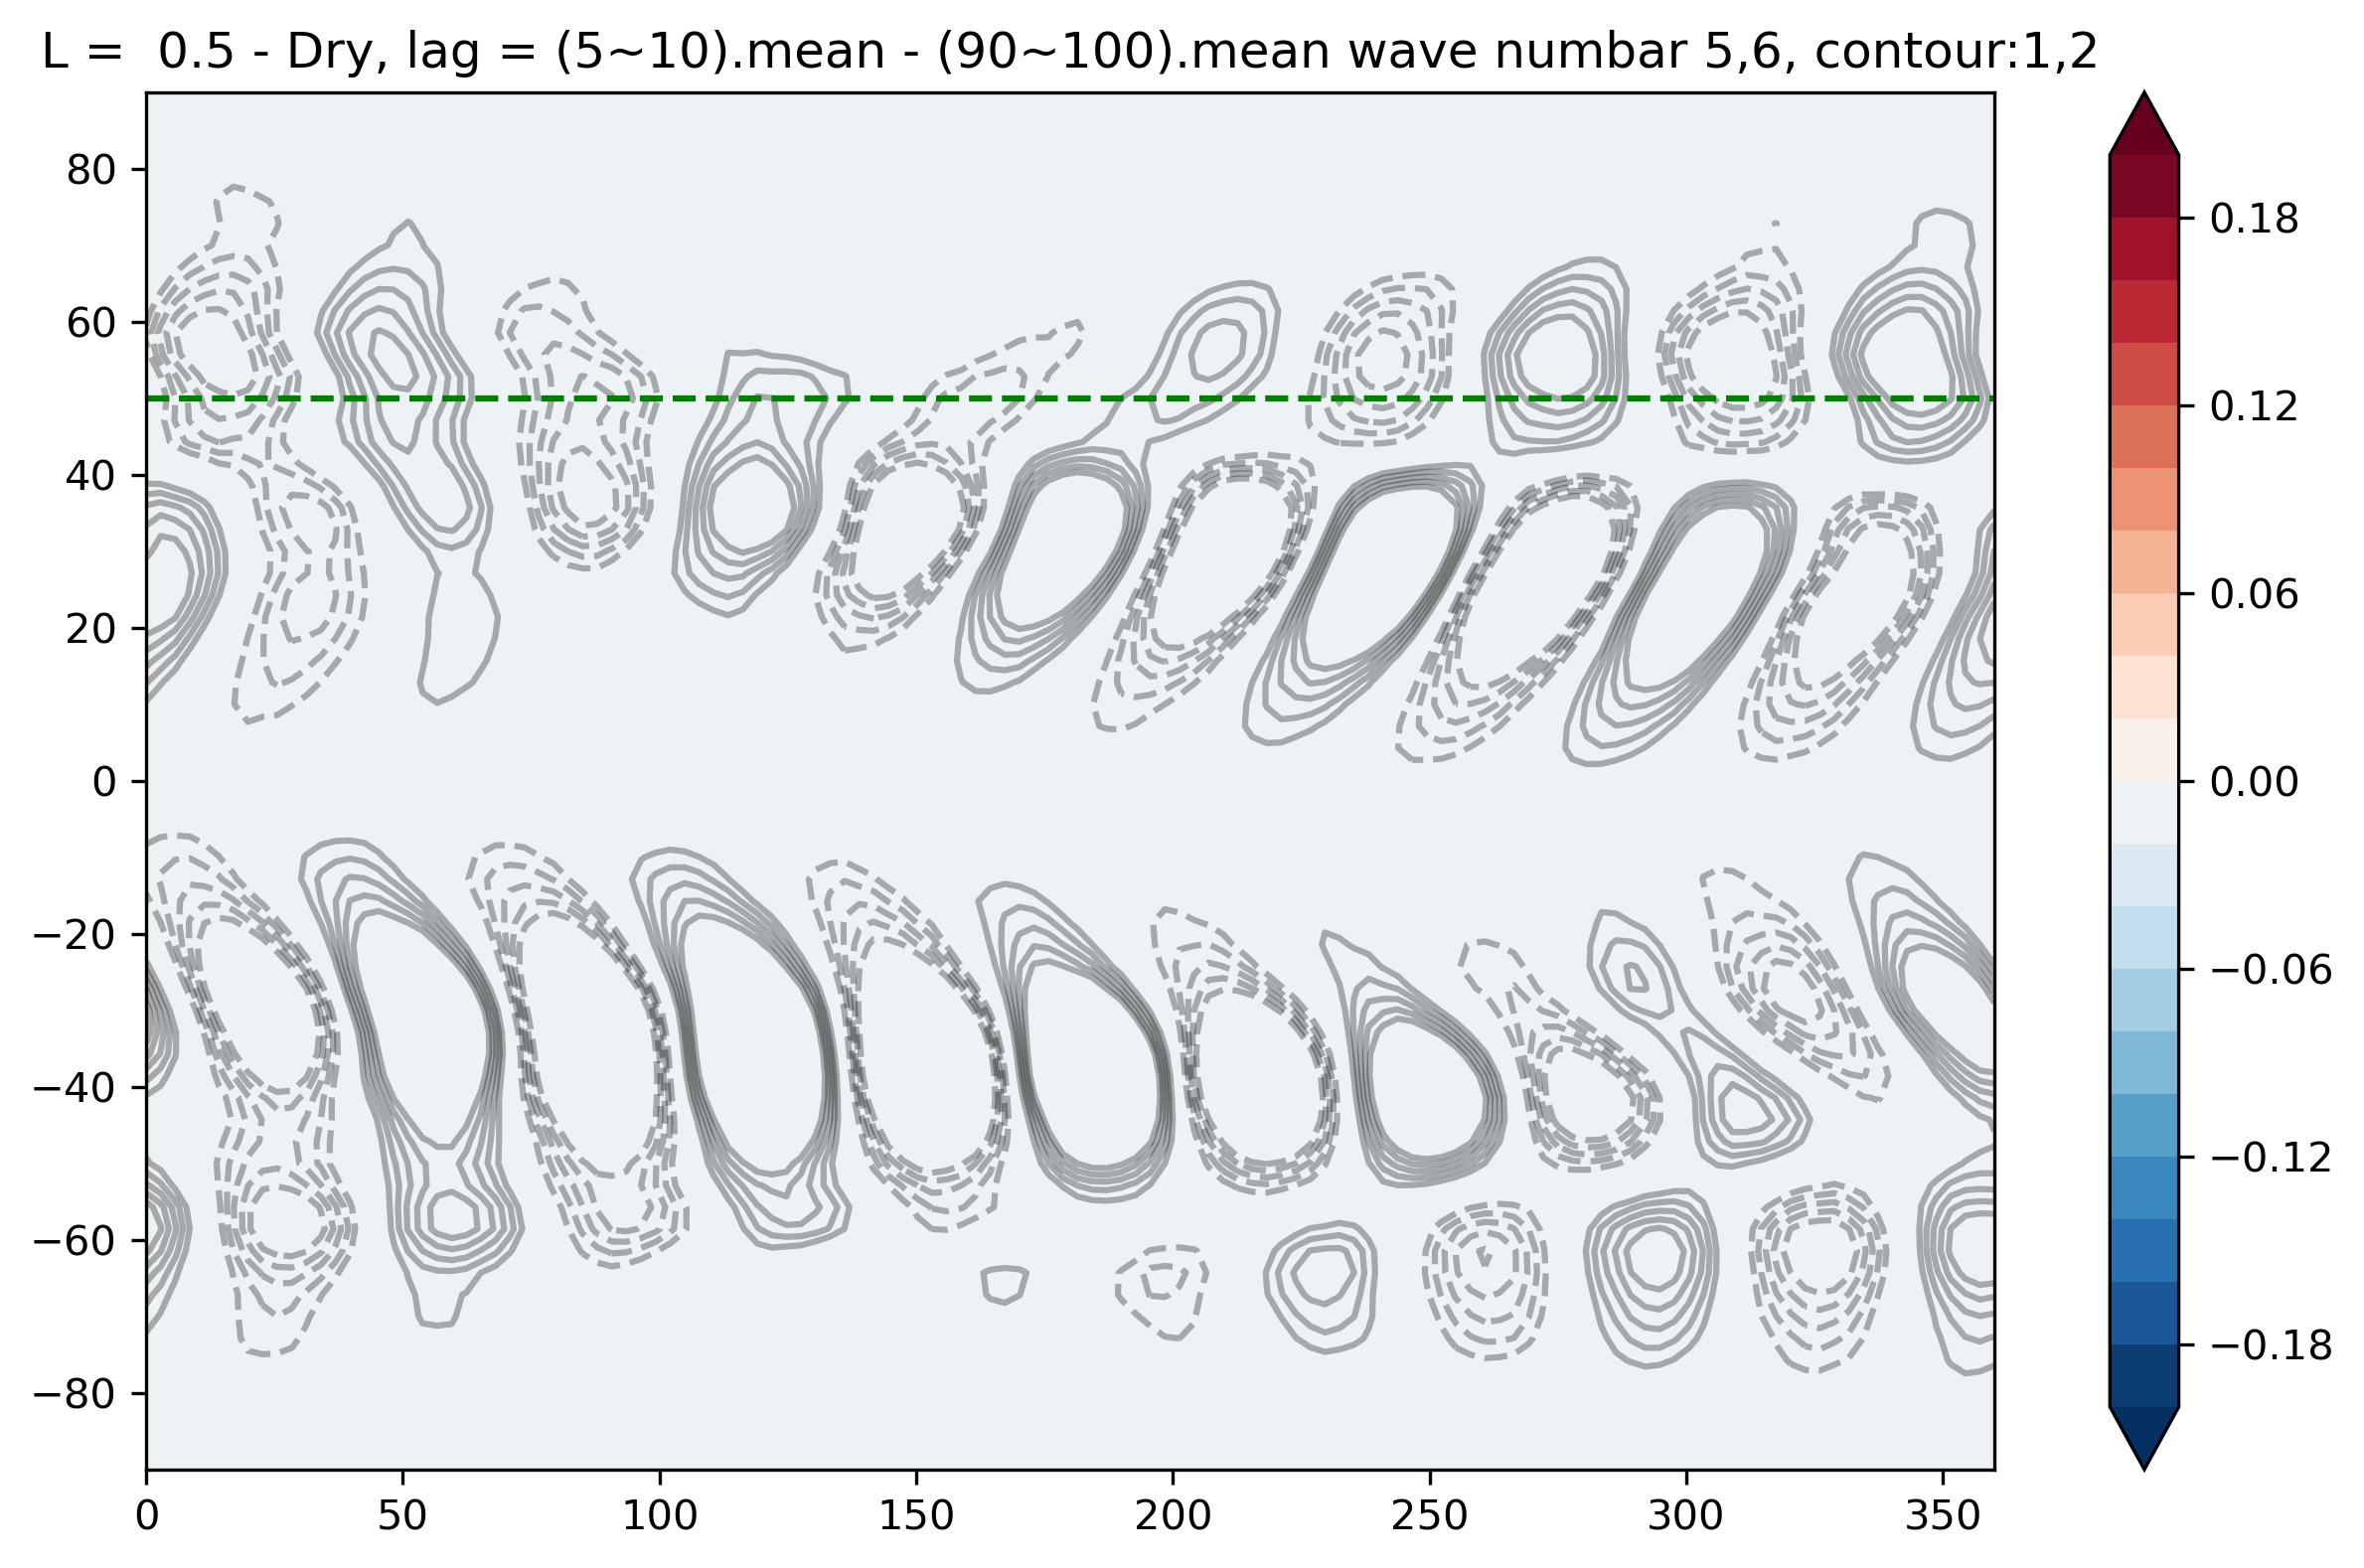

In [78]:
# tmp_z_lag_5_20          = tmp_z_lag_5_20.reshape([78000,64,128])
# tmp_prec_wn1_lag_5_20   = tmp_prec_wn1_lag_5_20.reshape([78000,64,128])
# tmp_z_wn5_6_lag_5_20    = tmp_z_wn5_6_lag_5_20.reshape([78000,64,128])
# tmp_z_wn1_2_lag_5_20    = tmp_z_wn1_2_lag_5_20.reshape([78000,64,128])

# tmp_z_lag_90_100         = tmp_z_lag_90_100.reshape([78000,64,128])
# tmp_prec_wn1_lag_90_100   = tmp_prec_wn1_lag_90_100.reshape([78000,64,128])
# tmp_z_wn5_6_lag_90_100   = tmp_z_wn5_6_lag_90_100.reshape([78000,64,128])
# tmp_z_wn1_2_lag_90_100    = tmp_z_wn1_2_lag_90_100.reshape([78000,64,128])


final_5_20_minus_90_100 = ((tmp_z_wn1_2_lag_5_20[time_idx_positive,:,:].mean(axis=(0))-tmp_z_wn1_2_lag_5_20[time_idx_positive,:,:].mean(axis=(0,2))[:,np.newaxis]) \
                         - (tmp_z_wn1_2_lag_90_100[time_idx_positive,:,:].mean(axis=(0))-tmp_z_wn1_2_lag_90_100[time_idx_positive,:,:].mean(axis=(0,2))[:,np.newaxis])) \
                         - ((tmp_z_wn1_2_lag_5_20[time_idx_negative,:,:].mean(axis=(0))-tmp_z_wn1_2_lag_5_20[time_idx_negative,:,:].mean(axis=(0,2))[:,np.newaxis]) \
                         - (tmp_z_wn1_2_lag_90_100[time_idx_negative,:,:].mean(axis=(0))-tmp_z_wn1_2_lag_90_100[time_idx_negative,:,:].mean(axis=(0,2))[:,np.newaxis]))


final_contour_5_20_minus_90_100 = (tmp_z_wn5_6_lag_5_20[time_idx_positive,:,:].mean(axis=(0))-tmp_z_wn5_6_lag_5_20[time_idx_positive,:,:].mean(axis=(0,2))[:,np.newaxis]) \
                                - (tmp_z_wn5_6_lag_90_100[time_idx_positive,:,:].mean(axis=(0))-tmp_z_wn5_6_lag_90_100[time_idx_positive,:,:].mean(axis=(0,2))[:,np.newaxis]) \
                                - (tmp_z_wn5_6_lag_5_20[time_idx_negative,:,:].mean(axis=(0))-tmp_z_wn5_6_lag_5_20[time_idx_negative,:,:].mean(axis=(0,2))[:,np.newaxis]) \
                                - (tmp_z_wn5_6_lag_90_100[time_idx_negative,:,:].mean(axis=(0))-tmp_z_wn5_6_lag_90_100[time_idx_negative,:,:].mean(axis=(0,2))[:,np.newaxis])
x = np.linspace(0,360,128)
y = np.linspace(-90,90,64)
xx, yy = np.meshgrid(x,y)


plt.figure(figsize=(10,6), dpi=300.)
CS = plt.contourf(xx,yy,    final_5_20_minus_90_100 - final_5_20_minus_90_100, cmap="RdBu_r", levels=np.linspace(-0.2,0.2,21), extend="both")
# CS = plt.contourf(xx,yy,tmp_vor_wn1[:,:,:].mean(axis=(0))-tmp_vor_wn1[:,:,:].mean(axis=(0,2))[:,np.newaxis])

# plt.contour(xx,yy,tmp_prec_wn1_lag[day,time_idx_positive,:,:].mean(axis=(0)))
plt.contour(xx,yy,   final_contour_5_20_minus_90_100_PR50 - final_contour_5_20_minus_90_100 , colors="Black", levels=np.linspace(0.1,0.25,5), alpha = 0.3)
plt.contour(xx,yy,   final_contour_5_20_minus_90_100_PR50 - final_contour_5_20_minus_90_100, colors="Black", linestyles='--', levels=np.linspace(-0.25,-0.1,5), alpha = 0.3)
# plt.contour(xx,yy, tmp_prec_wn1_lag_5_20[time_idx_positive,:,:].mean(axis=(0)) - tmp_prec_wn1_lag_90_100[time_idx_positive,:,:].mean(axis=(0)), colors="Black", levels=11, alpha = 0.3)


#plt.ylim([-30,30])
plt.hlines(y=50, xmin=0, xmax=360, colors="Green", linestyle="--", label="Annular mode center")

plt.colorbar(CS)
plt.title("L =  0.5 - Dry, lag = (5~10).mean - (90~100).mean wave numbar 5,6, contour:1,2")
print(PR)

In [64]:
# final_5_20_minus_90_100_PR50         = final_5_20_minus_90_100
# final_contour_5_20_minus_90_100_PR50 = final_contour_5_20_minus_90_100
# tmp_prec_wn1_lag_5_20_90_100_PR50    = tmp_prec_wn1_lag_5_20[time_idx_positive,:,:].mean(axis=(0)) - tmp_prec_wn1_lag_90_100[time_idx_positive,:,:].mean(axis=(0))

In [49]:
tmp_prec_wn1_lag_90_100[time_idx_positive,:,:].mean(axis=(0)).min()

0.002681276682714578

0


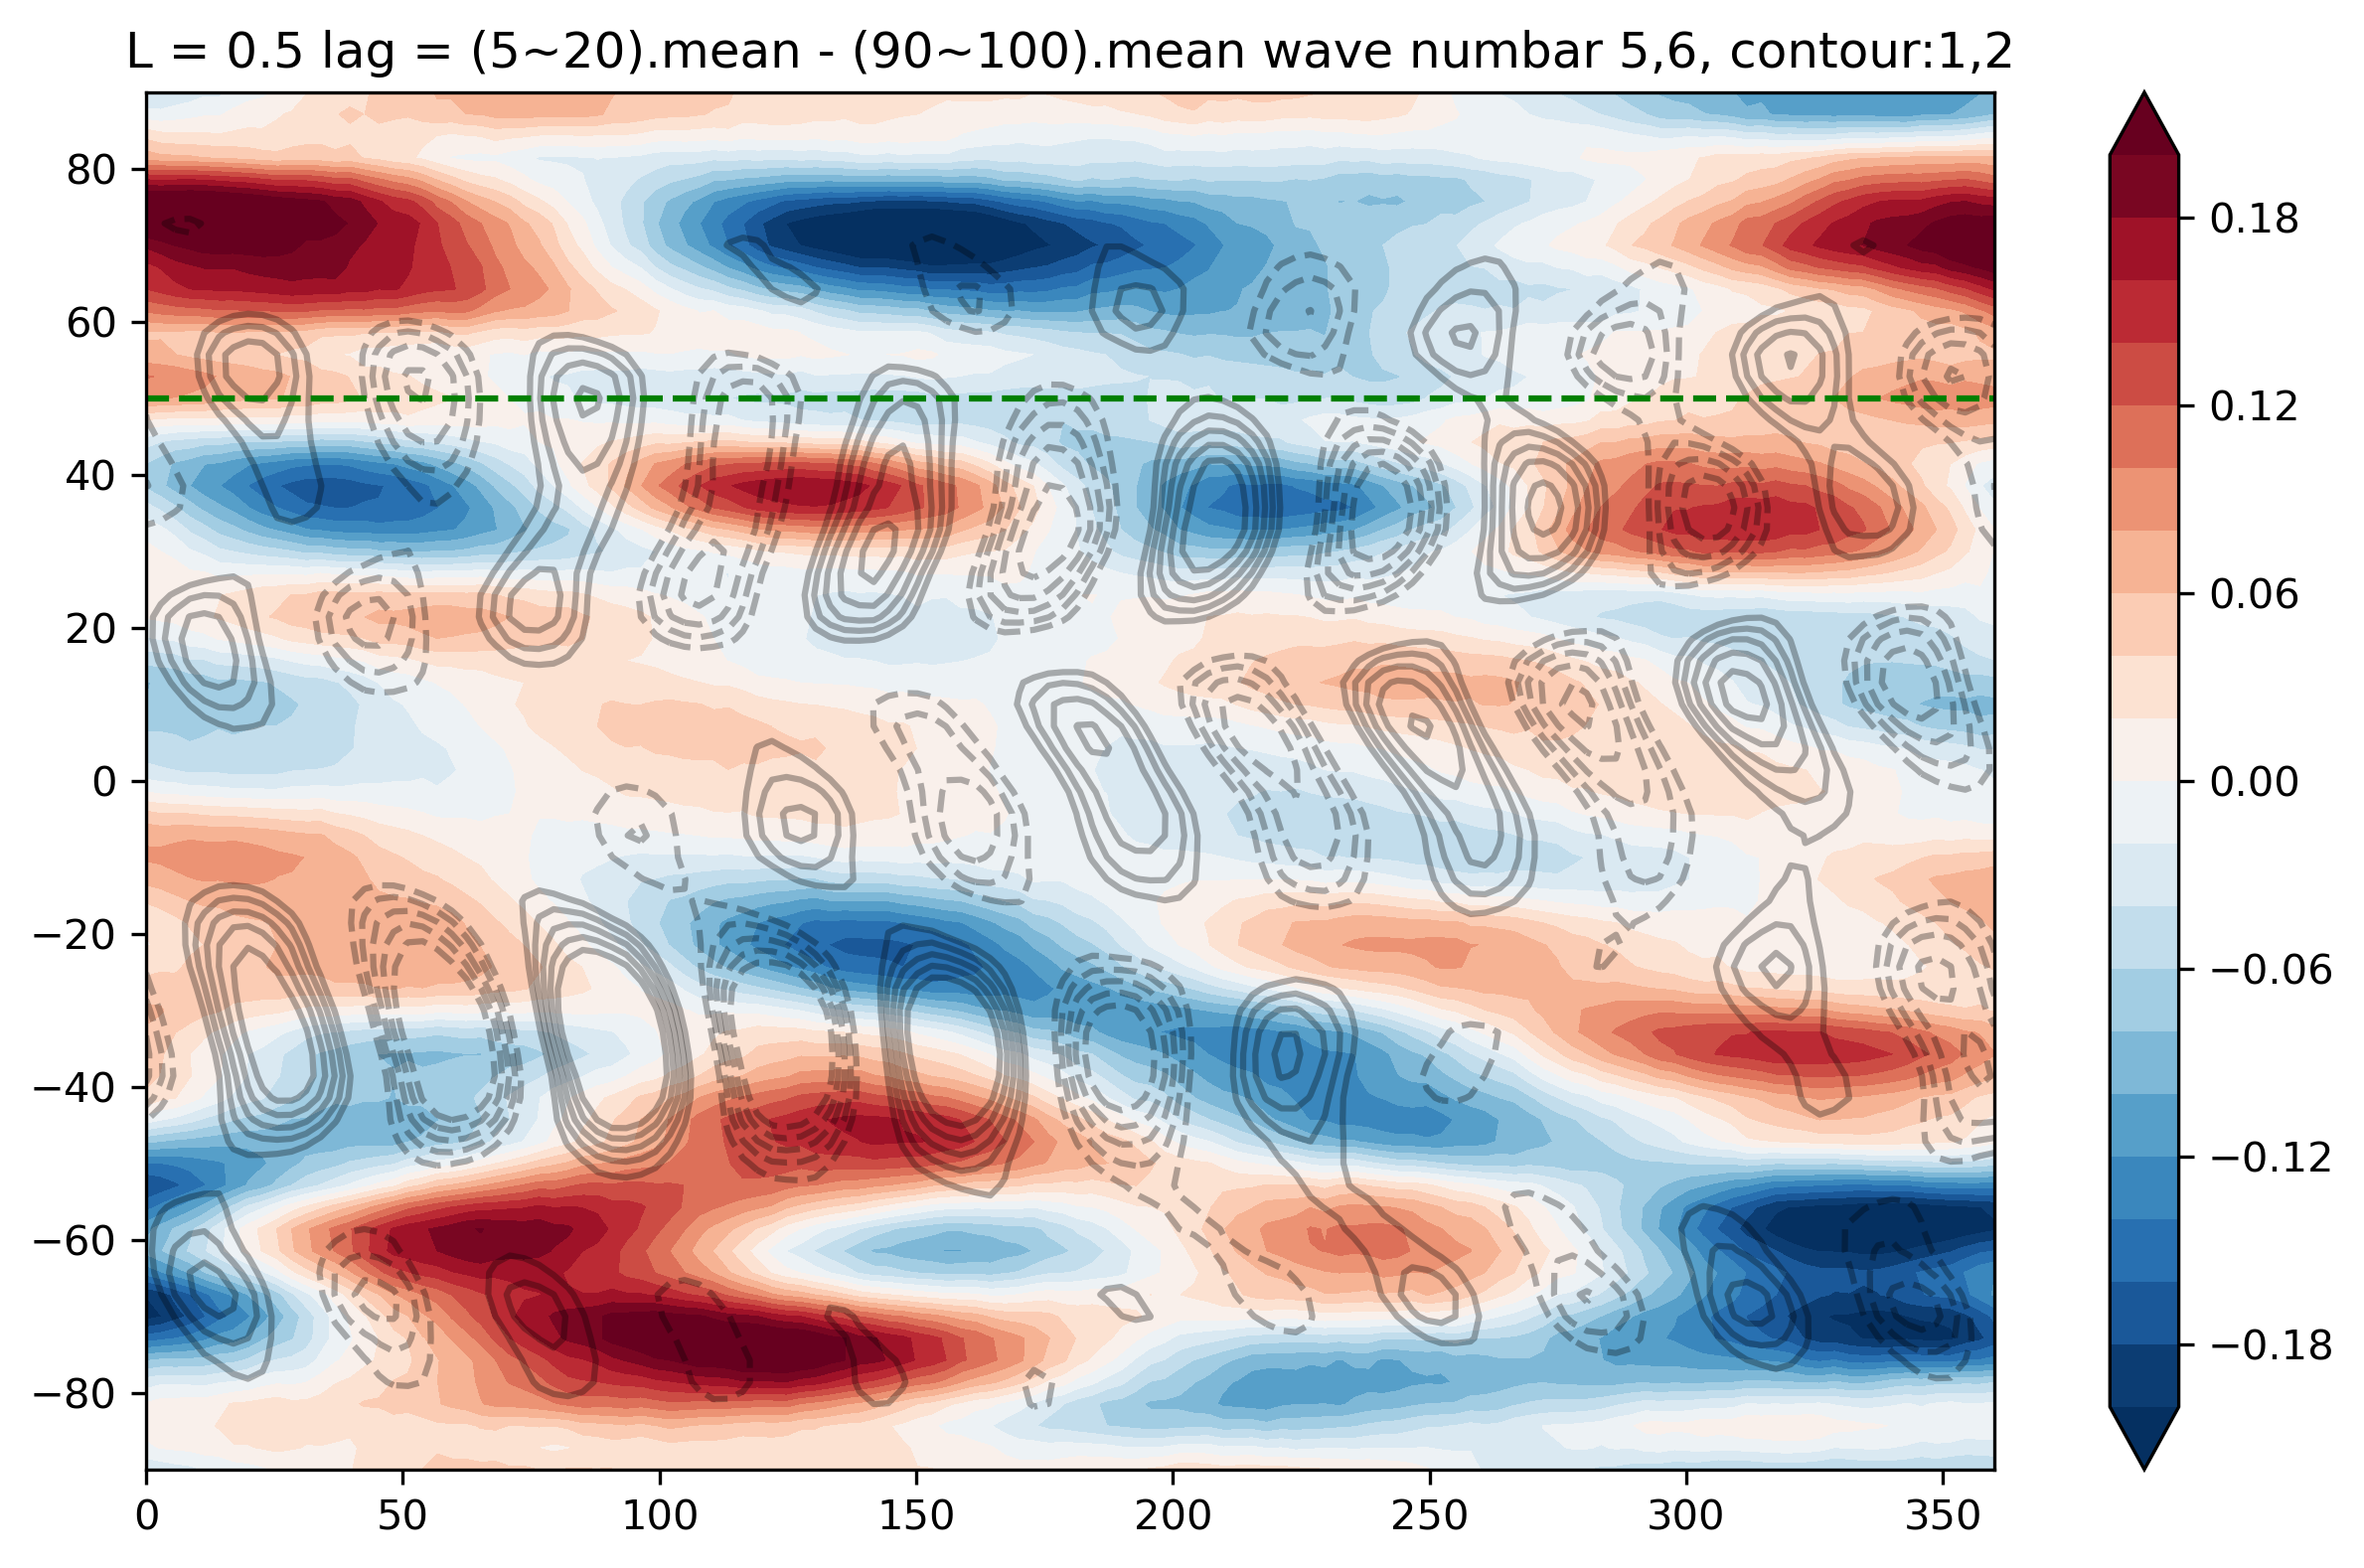

In [44]:
# # tmp_z_lag_5_20          = tmp_z_lag_5_20.reshape([78000,64,128])
# # tmp_prec_wn1_lag_5_20   = tmp_prec_wn1_lag_5_20.reshape([78000,64,128])
# # tmp_z_wn5_6_lag_5_20    = tmp_z_wn5_6_lag_5_20.reshape([78000,64,128])
# # tmp_z_wn1_2_lag_5_20    = tmp_z_wn1_2_lag_5_20.reshape([78000,64,128])

# # tmp_z_lag_90_100         = tmp_z_lag_90_100.reshape([78000,64,128])
# # tmp_prec_wn1_lag_90_100   = tmp_prec_wn1_lag_90_100.reshape([78000,64,128])
# # tmp_z_wn5_6_lag_90_100   = tmp_z_wn5_6_lag_90_100.reshape([78000,64,128])
# # tmp_z_wn1_2_lag_90_100    = tmp_z_wn1_2_lag_90_100.reshape([78000,64,128])


# # final_5_20_minus_90_100 = ((tmp_z_wn1_2_lag_5_20[time_idx_positive,:,:].mean(axis=(0))-tmp_z_wn1_2_lag_5_20[time_idx_positive,:,:].mean(axis=(0,2))[:,np.newaxis]) \
# #                          - (tmp_z_wn1_2_lag_90_100[time_idx_positive,:,:].mean(axis=(0))-tmp_z_wn1_2_lag_90_100[time_idx_positive,:,:].mean(axis=(0,2))[:,np.newaxis])) \
# #                          - ((tmp_z_wn1_2_lag_5_20[time_idx_negative,:,:].mean(axis=(0))-tmp_z_wn1_2_lag_5_20[time_idx_negative,:,:].mean(axis=(0,2))[:,np.newaxis]) \
# #                          - (tmp_z_wn1_2_lag_90_100[time_idx_negative,:,:].mean(axis=(0))-tmp_z_wn1_2_lag_90_100[time_idx_negative,:,:].mean(axis=(0,2))[:,np.newaxis]))


# # final_contour_5_20_minus_90_100 = (tmp_z_wn5_6_lag_5_20[time_idx_positive,:,:].mean(axis=(0))-tmp_z_wn5_6_lag_5_20[time_idx_positive,:,:].mean(axis=(0,2))[:,np.newaxis]) \
# #                                 - (tmp_z_wn5_6_lag_90_100[time_idx_positive,:,:].mean(axis=(0))-tmp_z_wn5_6_lag_90_100[time_idx_positive,:,:].mean(axis=(0,2))[:,np.newaxis]) \
# #                                 - (tmp_z_wn5_6_lag_5_20[time_idx_negative,:,:].mean(axis=(0))-tmp_z_wn5_6_lag_5_20[time_idx_negative,:,:].mean(axis=(0,2))[:,np.newaxis]) \
# #                                 - (tmp_z_wn5_6_lag_90_100[time_idx_negative,:,:].mean(axis=(0))-tmp_z_wn5_6_lag_90_100[time_idx_negative,:,:].mean(axis=(0,2))[:,np.newaxis])
# x = np.linspace(0,360,128)
# y = np.linspace(-90,90,64)
# xx, yy = np.meshgrid(x,y)


# plt.figure(figsize=(10,6), dpi=300.)
# CS = plt.contourf(xx,yy, final_5_20_minus_90_100_PR50, cmap="RdBu_r", levels=np.linspace(-0.2,0.2,21), extend="both")
# # CS = plt.contourf(xx,yy,tmp_vor_wn1[:,:,:].mean(axis=(0))-tmp_vor_wn1[:,:,:].mean(axis=(0,2))[:,np.newaxis])

# # plt.contour(xx,yy,tmp_prec_wn1_lag[day,time_idx_positive,:,:].mean(axis=(0)))
# plt.contour(xx,yy, final_contour_5_20_minus_90_100_PR50, colors="Black", levels=np.linspace(0.1,0.25,5), alpha = 0.3)
# plt.contour(xx,yy, final_contour_5_20_minus_90_100_PR50, colors="Black", linestyles='--', levels=np.linspace(-0.25,-0.1,5), alpha = 0.3)


# #plt.ylim([-30,30])
# plt.hlines(y=50, xmin=0, xmax=360, colors="Green", linestyle="--", label="Annular mode center")

# plt.colorbar(CS)
# plt.title("L = 0.5 lag = (5~20).mean - (90~100).mean wave numbar 5,6, contour:1,2")
# print(PR)

# try wave number 1-2 and 5-6

In [290]:
u_file_path = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/u/PR{PR}_500_20000day_6hourly_u.dat"
with h5py.File(u_file_path) as f:
    print(f.keys())
    u = f["u"][:, level_index,:]
u -= u.mean(axis=0)
#####################################################


<KeysViewHDF5 ['u']>


In [47]:
def read_var_at_level(PR, var, start_day, end_day, level_index):
    import h5py
    if PR  in [0, 10, 30]:
        common_path = "/data92/PeterChang/back_to_master1220"
    else:
        common_path = "/data92/PeterChang2/"
        
    y_dim = 64
    x_dim = 128
    var_all = np.zeros(((int((end_day - start_day)*4), y_dim, x_dim)))

    aa = 0
    for day in range(start_day, end_day, 25):
        path = common_path + f"/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/HSt42_{PR}/RH80_PR{PR}_20000day_startfrom_{day}day_final.dat"
        with h5py.File(path) as f:
            var_all[aa:aa+100] = f[var][:, level_index,:]#.mean(axis=1)
        aa += 100
    return var_all
    



In [48]:
v = read_var_at_level(PR, "grid_v_c_xyzt", 500, 20000, level_index) 
v -= v.mean(axis=0)

u = read_var_at_level(PR, "grid_u_c_xyzt", 500, 20000, level_index) 
u -= u.mean(axis=0)

In [1279]:
div = read_var_at_level(PR, "grid_div_xyzt", 500, 20000, level_index) 
div -= div.mean(axis=0)

vor = read_var_at_level(PR, "grid_vor_xyzt", 500, 20000, level_index) 
vor -= vor.mean(axis=0)

In [ ]:
neg_uD = -u*div
v_vor = v * vor

(78000, 64, 128)

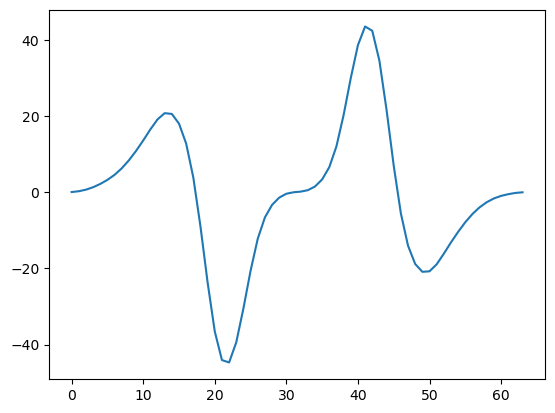

In [1280]:
plt.figure()
plt.plot((u*v).mean(axis=(0,2)))
u.shape

In [10]:
if 'z_wn1' in globals():
    del z_wn1
if 'prec_wn1' in globals():
    del prec_wn1
if 'vor_wn1' in globals():
    del vor_wn1

if 'EMF_wn1_2' in globals():
    del EMF_wn1_2

if 'uD_wn1_2' in globals():
    del uD_wn1_2
    
if 'v_vor_wn1_2' in globals():
    del v_vor_wn1_2


prec_wn1   = fft_filtering(prec,dim=2,wave_numbers=[1,2])
# prec_wn1   = fft_filtering(prec,dim=2,wave_numbers=[3,4])

z_wn1_2      = fft_filtering(z,dim=2,wave_numbers=[1,2,3,4,5,6]) # wave number 1~2 for shading
EMF_wn1_2     = fft_filtering(u*v,dim=2,wave_numbers=[1,2,3,4,5,6]) # wave number 1~2 for shading
uD_wn1_2     =  fft_filtering(-u*div,dim=2,wave_numbers=[1]) # wave number 1~2 for shading
v_vor_wn1_2   =  fft_filtering(v_vor,dim=2,wave_numbers=[1]) # wave number 1~2 for shading


# z_wn1      = fft_filtering(z,dim=2,wave_numbers=[5,6])
# z_wn1      = fft_filtering(z,dim=2,wave_numbers=[5,6])
# z_wn5_6      = fft_filtering(z,dim=2,wave_numbers=[5,6]) # wave number 5~6 for contour

NameError: name 'fft_filtering' is not defined

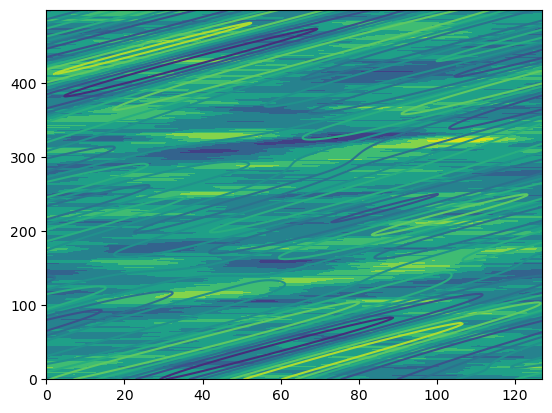

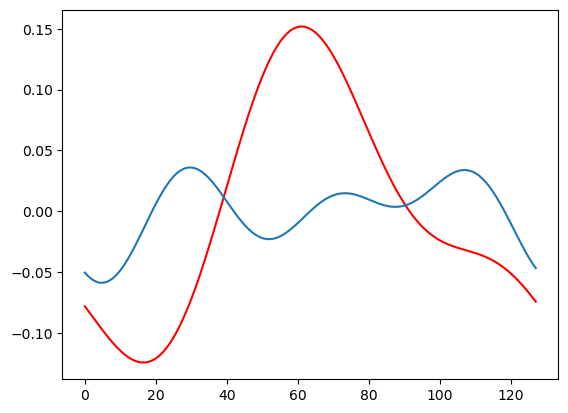

In [1339]:
plt.figure()
plt.contourf(prec_wn1[1000:1500,lat_cond,:].mean(axis=1))
plt.contour(prec_recon[1000:1500,:,:].mean(axis=1))

plt.figure()
plt.plot(prec_wn1[100,lat_cond,:].mean(axis=0),'r')
plt.plot(prec_recon[100,:,:].mean(axis=0))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_11121/3280097037.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


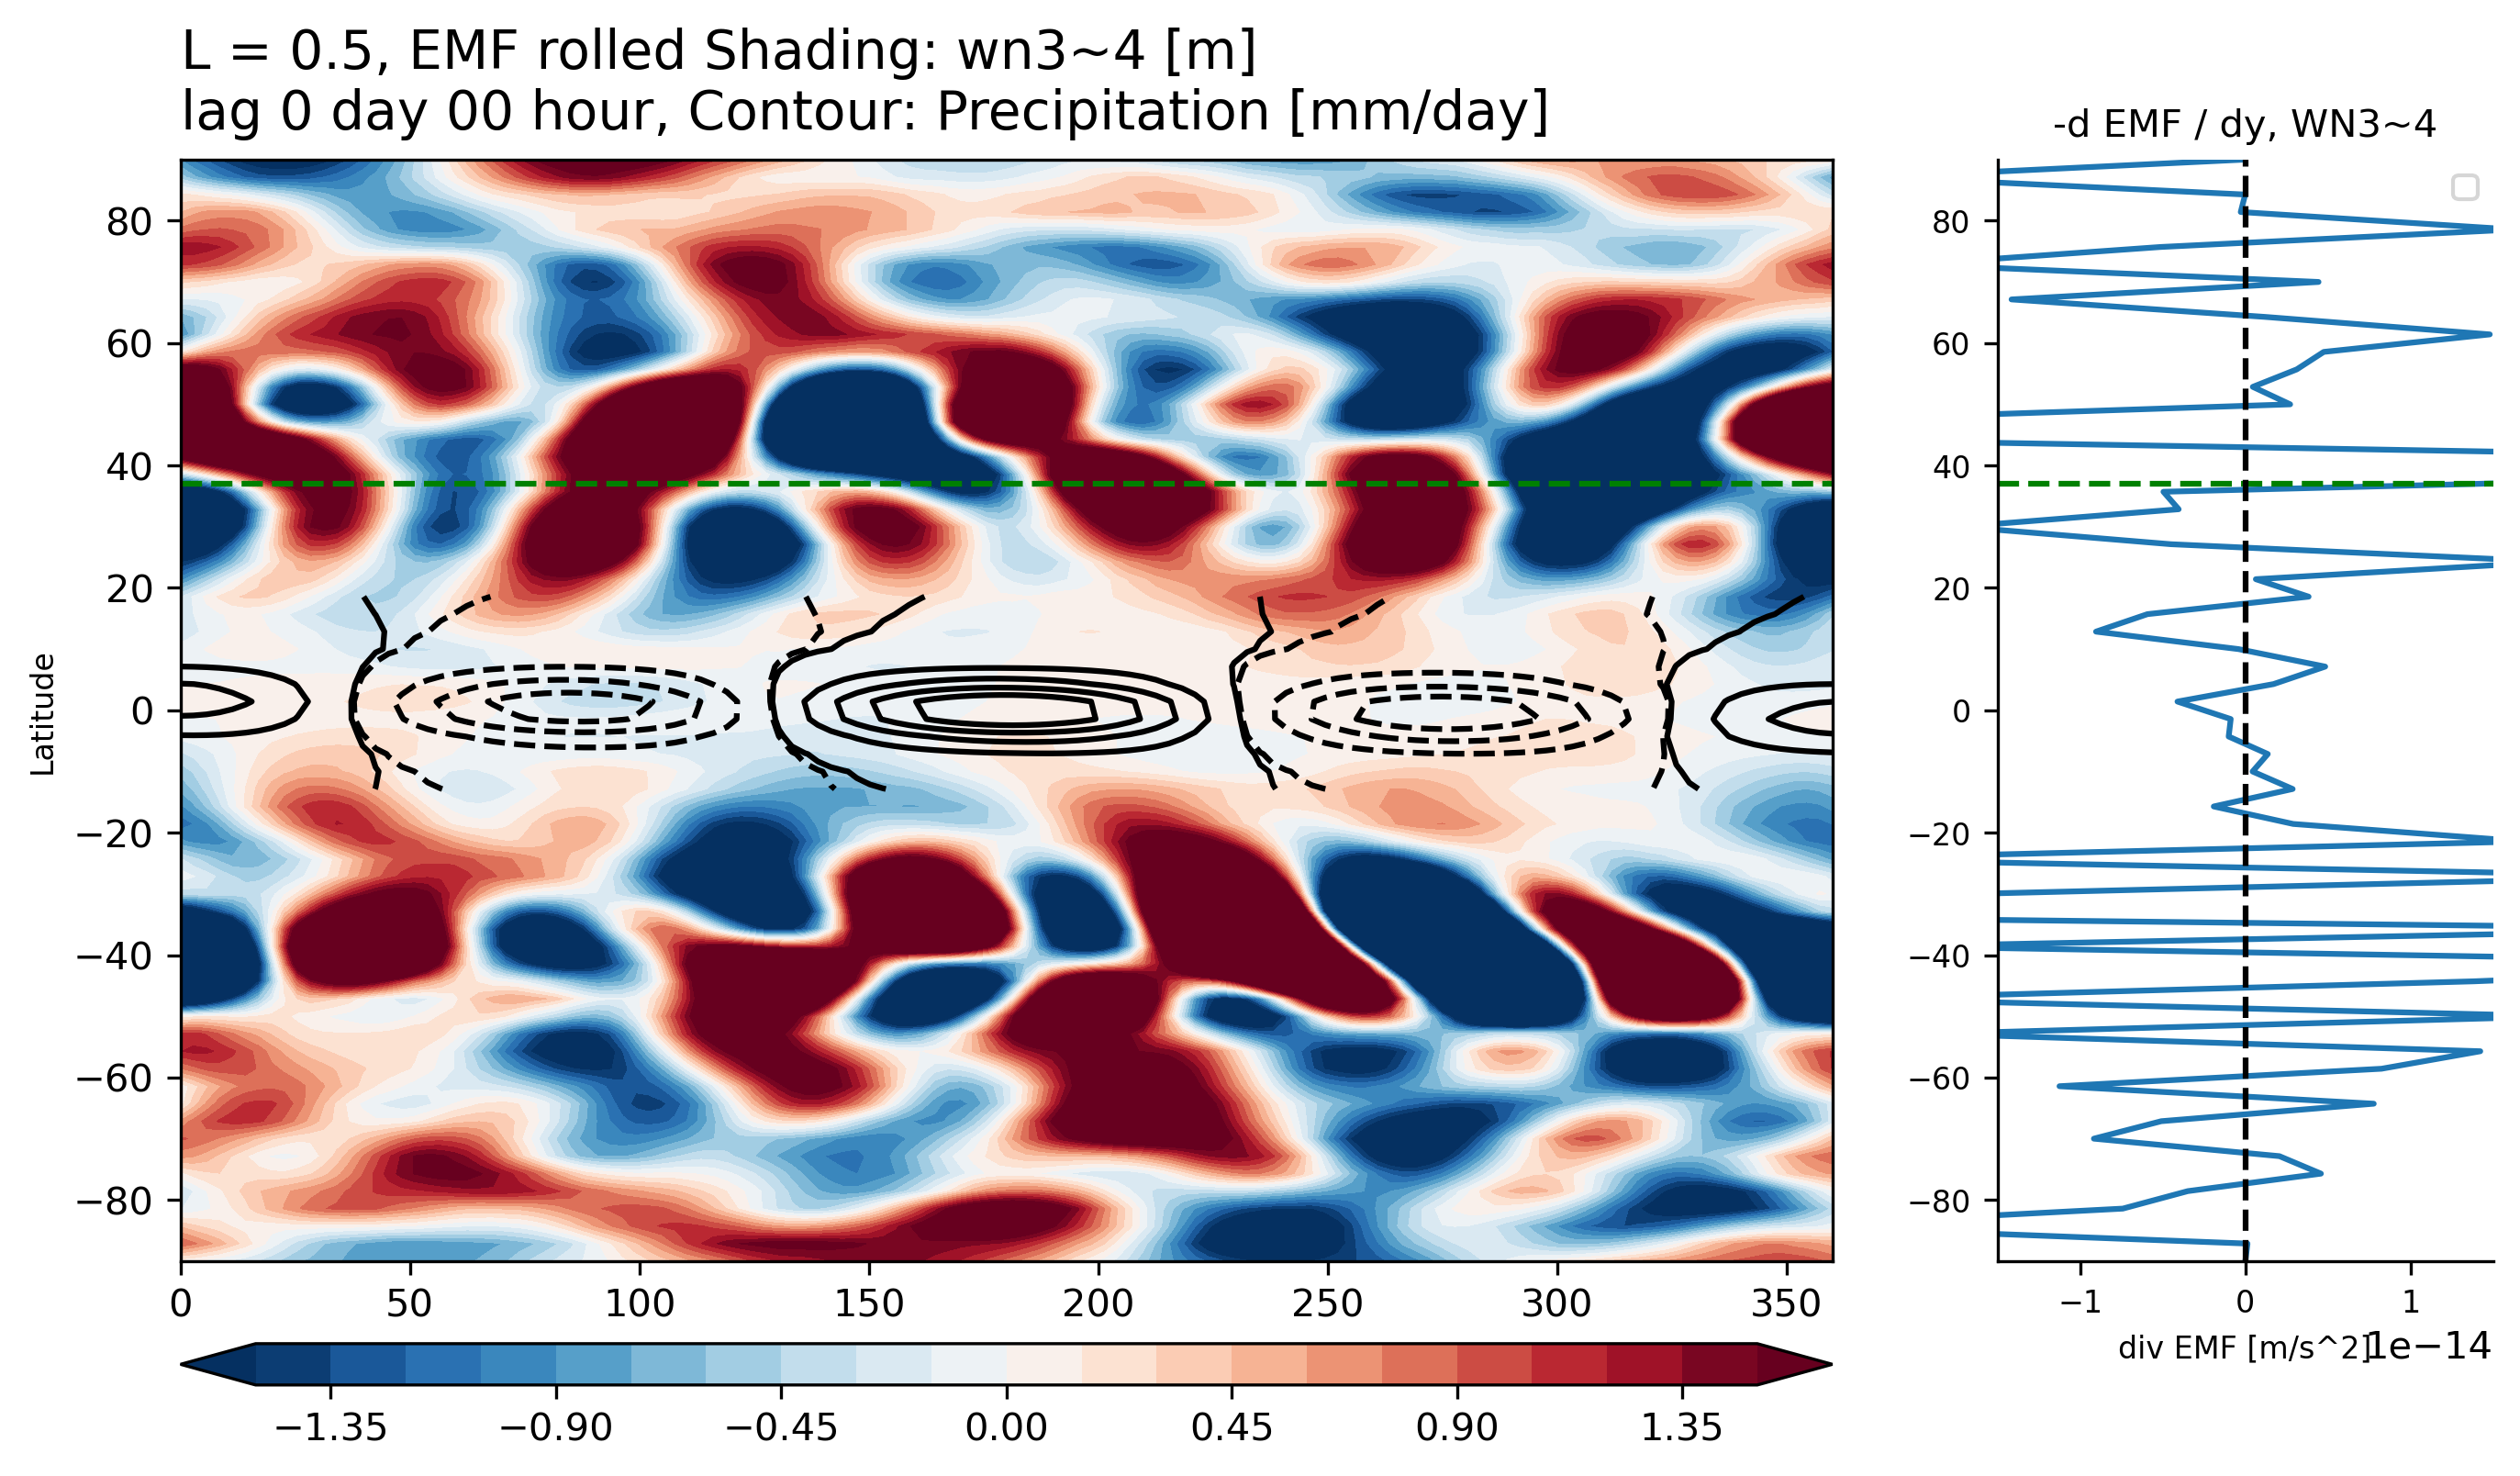

In [642]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import copy

# Assume all required data (`prec_recon`, `z`, `prec_wn1`, etc.) are already defined
y = np.linspace(-90, 90, 64)

# Define optional flags for saving and displaying plots
save_plots =  False #True
show_plots =  True #False
save_dir = f"/data92/PeterChang/Figs-113-1Seminar/Gill_wn12_56_PR{PR}/"

variables_to_delete = ['tmp', 'tmp_z', 'tmp_prec_wn1', 'tmp_z_wn1', 'tmp_EMF_wn1']
for variable in variables_to_delete:
    if variable in globals():
        del globals()[variable]

# Initialize required variables
tmp              = prec_recon.mean(axis=1)[:, :]
tmp_z            = copy.deepcopy(z[:, :, :].reshape([78000 * 64, 128]))
tmp_prec_wn1     = copy.deepcopy(prec_wn1[:, :, :].reshape([78000 * 64, 128]))
tmp_z_wn5_6      = copy.deepcopy(z_wn5_6[:, :, :].reshape([78000 * 64, 128]))
tmp_z_wn1_2      = copy.deepcopy(z_wn1_2[:, :, :].reshape([78000 * 64, 128]))
tmp_EMF_wn1_2    = copy.deepcopy(EMF_wn1_2[:, :, :].reshape([78000 * 64, 128]))

# Position information for maximum points
posi_time, posi_x = np.where(tmp == np.max(tmp, axis=1)[:, np.newaxis])

# Process data for the specified lag
lags = 5 * 4
aa = 0
for lag in range(0 * 4, 0 * 4 + 1):
    tmp              = prec_recon.mean(axis=1)[:, :]
    tmp_z            = copy.deepcopy(z[:, :, :].reshape([78000 * 64, 128]))
    tmp_prec_wn1     = copy.deepcopy(prec_wn1[:, :, :].reshape([78000 * 64, 128]))
    tmp_z_wn5_6      = copy.deepcopy(z_wn5_6[:, :, :].reshape([78000 * 64, 128]))
    tmp_z_wn1_2      = copy.deepcopy(z_wn1_2[:, :, :].reshape([78000 * 64, 128]))
    tmp_EMF_wn1_2    = copy.deepcopy(EMF_wn1_2[:, :, :].reshape([78000 * 64, 128]))

    # Adjust positions based on max values
    posi_time, posi_x = np.where(tmp == np.max(tmp, axis=1)[:, np.newaxis])
    for i in range(tmp.shape[0]):
        if i >= (78000 - lag):
            continue
        shift = 64 - posi_x[i]
        
        tmp[(i + lag), :]                              = np.roll(tmp[(i + lag), :], shift)
        tmp_z[(i + lag) * 64:((i + lag) + 1) * 64, :]  = np.roll(tmp_z[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_prec_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :] = np.roll(tmp_prec_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_z_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :]  = np.roll(tmp_z_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_EMF_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :] = np.roll(tmp_EMF_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_z_wn5_6[(i + lag) * 64:((i + lag) + 1) * 64, :]  = np.roll(tmp_z_wn5_6[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)

    # Reshape for plotting
    tmp_prec_wn1 = tmp_prec_wn1.reshape([78000, 64, 128])
    tmp_z_wn5_6  = tmp_z_wn5_6.reshape([78000, 64, 128])
    tmp_z_wn1_2  = tmp_z_wn1_2.reshape([78000, 64, 128])
    tmp_EMF_wn1_2 = tmp_EMF_wn1_2.reshape([78000, 64, 128])
    tmp_z        = tmp_z.reshape([78000, 64, 128])

    # Prepare data for main plot
    x = np.linspace(0, 360, 128)
    y = np.linspace(-90, 90, 64)
    xx, yy = np.meshgrid(x, y)
    final         = (tmp_z_wn1_2[:, :, :].mean(axis=(0)) - tmp_z_wn1_2[:, :, :].mean(axis=(0, 2))[:, np.newaxis])
    final_EMF     = (tmp_EMF_wn1_2[:, :, :].mean(axis=(0)) - tmp_EMF_wn1_2[:, :, :].mean(axis=(0, 2))[:, np.newaxis])
    final_contour = (tmp_z_wn5_6[:, :, :].mean(axis=(0)) - tmp_z_wn5_6[:, :, :].mean(axis=(0, 2))[:, np.newaxis])
    final_prec    = (tmp_prec_wn1[:, :, :].mean(axis=(0)) - tmp_prec_wn1[:, :, :].mean(axis=(0, 2))[:, np.newaxis])
    

    # Plotting the main figure
    # fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    fig = plt.figure(figsize=(12, 5), dpi=300)
    ax1 = fig.add_axes([0.05, 0.1, 0.5, 0.8])  # Adjust the size/position as needed
    
    CS = ax1.contourf(xx, yy, final_EMF, cmap="RdBu_r", levels=np.linspace(-1.5,1.5,21), extend="both")
    # ax1.contour(xx, yy, final_contour, colors="Black", levels=np.linspace(0.2, 1, 5), alpha=0.3)
    # ax1.contour(xx, yy, final_contour, colors="Black", linestyles='--', levels=np.linspace(-1, -0.2, 5), alpha=0.3)
    ax1.contour(xx[27:39], yy[27:39], final_prec[27:39], colors="Black", levels=np.linspace(0.005, 0.6, 5))
    ax1.contour(xx[27:39], yy[27:39], final_prec[27:39], colors="Black", linestyles='--', levels=np.linspace(-0.6, -0.005, 5))
    
    ax1.hlines(y=37, xmin=0, xmax=360, colors="Green", linestyle="--", label="Annular mode center")

    # Calculate the day and hour for title
    day = lag // 4
    hour = (lag % 4) * 6
    ax1.set_title(f"L = 0.5, EMF rolled Shading: wn3~4 [m]\nlag {day} day {hour:02d} hour, Contour: Precipitation [mm/day]", pad=8, fontsize=14, loc="left")
    cax1 = fig.add_axes([0.05, 0.01, 0.5, 0.03])  # Place directly below ax1
    cbar1 = plt.colorbar(CS, orientation="horizontal", pad=0.1, cax=cax1)
    
    # Add an inset line plot in a specific location within the main figure
    ax2 = fig.add_axes([0.6, 0.1, 0.15, 0.8])  # Adjust the position and size of the line plot
    dEMF_wn3_dy = np.zeros(64)
    EMF_wn3_mean = np.mean(final_EMF, axis=1)

    for i in range(1, 64 - 1):
        dEMF_wn3_dy[i] = -(EMF_wn3_mean[i + 1] - EMF_wn3_mean[i - 1]) / (np.deg2rad(y[i + 1]) - np.deg2rad(y[i - 1]))

    # Customize the inset plot
    ax2.plot(dEMF_wn3_dy, y)
    ax2.hlines(y=37, xmin=-1.5E-14, xmax=1.5E-14, colors="Green", linestyle="--")
    ax2.vlines(x=0, ymin=-90, ymax=90, colors="Black", linestyle="--")
    ax2.spines["right"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax2.set_xlabel("div EMF [m/s^2]", fontsize=8)
    ax1.set_ylabel("Latitude", fontsize=8)
    ax2.tick_params(axis='both', labelsize=8)
    ax2.set_title("-d EMF / dy, WN3~4", fontsize=10)
    ax2.legend(fontsize=8)
    ax2.set_ylim([-90,90])
    ax2.set_xlim([-1.5E-14,1.5E-14])

    plt.tight_layout()
    # Saving and displaying the plot based on the flags
    if save_plots:
        plt.savefig(f"{save_dir}{aa}.png", bbox_inches='tight', dpi=300)
    if show_plots:
        plt.show()
    else:
        plt.close(fig)  # Close to free memory if not displaying

    aa += 1


In [60]:
!cd $"/data92/PeterChang/Figs-113-1Seminar/Gill_wn12_56_PR50" && ffmpeg -r 5 -i %d.png -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -pix_fmt yuv420p WN12_5_PR50.mp4 -y


ffmpeg version 7.0.1 Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 12.4.0 (conda-forge gcc 12.4.0-0)
  configuration: --prefix=/home/PeterChang/miniconda3/envs/ML22 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1722545971544/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1722545971544/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1722545971544/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1722545971544/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --disable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-gnutls --enable-libmp3lame --enable-libvpx --enable-libass --enable-pthreads --enable-vaapi --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libaom --enabl

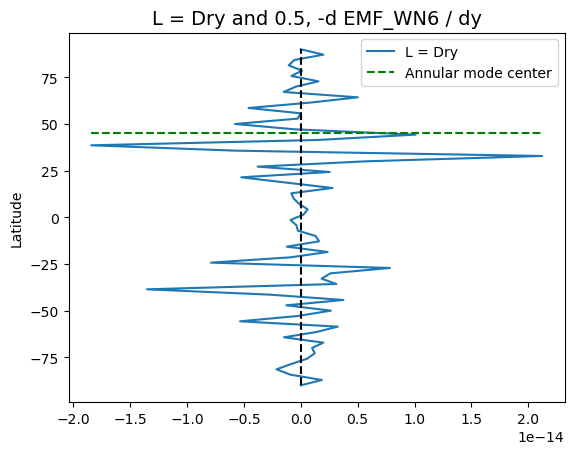

In [202]:
plt.figure(dpi=100)
# plt.plot(dEMF_wn3_dy_PR50,y, label="L = 0.5")
plt.plot(dEMF_wn3_dy,y, label="L = Dry")

plt.hlines(y=45, xmin=dEMF_wn3_dy.min(), xmax=dEMF_wn3_dy.max(), colors="Green", linestyle="--", label="Annular mode center")
plt.vlines(x=0, ymin=-90, ymax=90, colors="Black", linestyle="--")
plt.title("L = Dry and 0.5, -d EMF_WN6 / dy", fontsize=14)
plt.ylabel("Latitude")
plt.legend()

# plt.figure(dpi=100)
# plt.plot(dfinal_dy_PR50,y)
# plt.hlines(y=50, xmin=dfinal_dy_PR50.min(), xmax=dfinal_dy_PR50.max(), colors="Green", linestyle="--", label="Annular mode center")
# plt.vlines(x=0, ymin=-90, ymax=90, colors="Black", linestyle="--")
# plt.title("L = 0.5, d final / dy", fontsize=14)
# plt.ylabel("Latitude")





In [295]:
# final_lag_5 = final
# final_contour_lag_5 = final_contour
# tmp_final            = copy.deepcopy(final[:,:,:].reshape([78000*64,128]))
final_roll         = copy.deepcopy(final[:,:])
final_contour_roll = copy.deepcopy(final_contour[:,:])


# posi_time,posi_x = np.where(final == np.max(final ,axis=1)[:,np.newaxis])
posi_time,posi_x         = np.where(final == np.max(final, axis=1)[:,np.newaxis])
posi_time,posi_x_contour = np.where(final_contour == np.max(final_contour, axis=1)[:,np.newaxis])
print(final.shape)

for i in range(final.shape[0]):
        final_roll[i,:]                              = np.roll(final[i,:], 64-posi_x[32])
        final_contour_roll[i,:]                      = np.roll(final_contour[i,:], 64-posi_x_contour[32])
    


(64, 128)


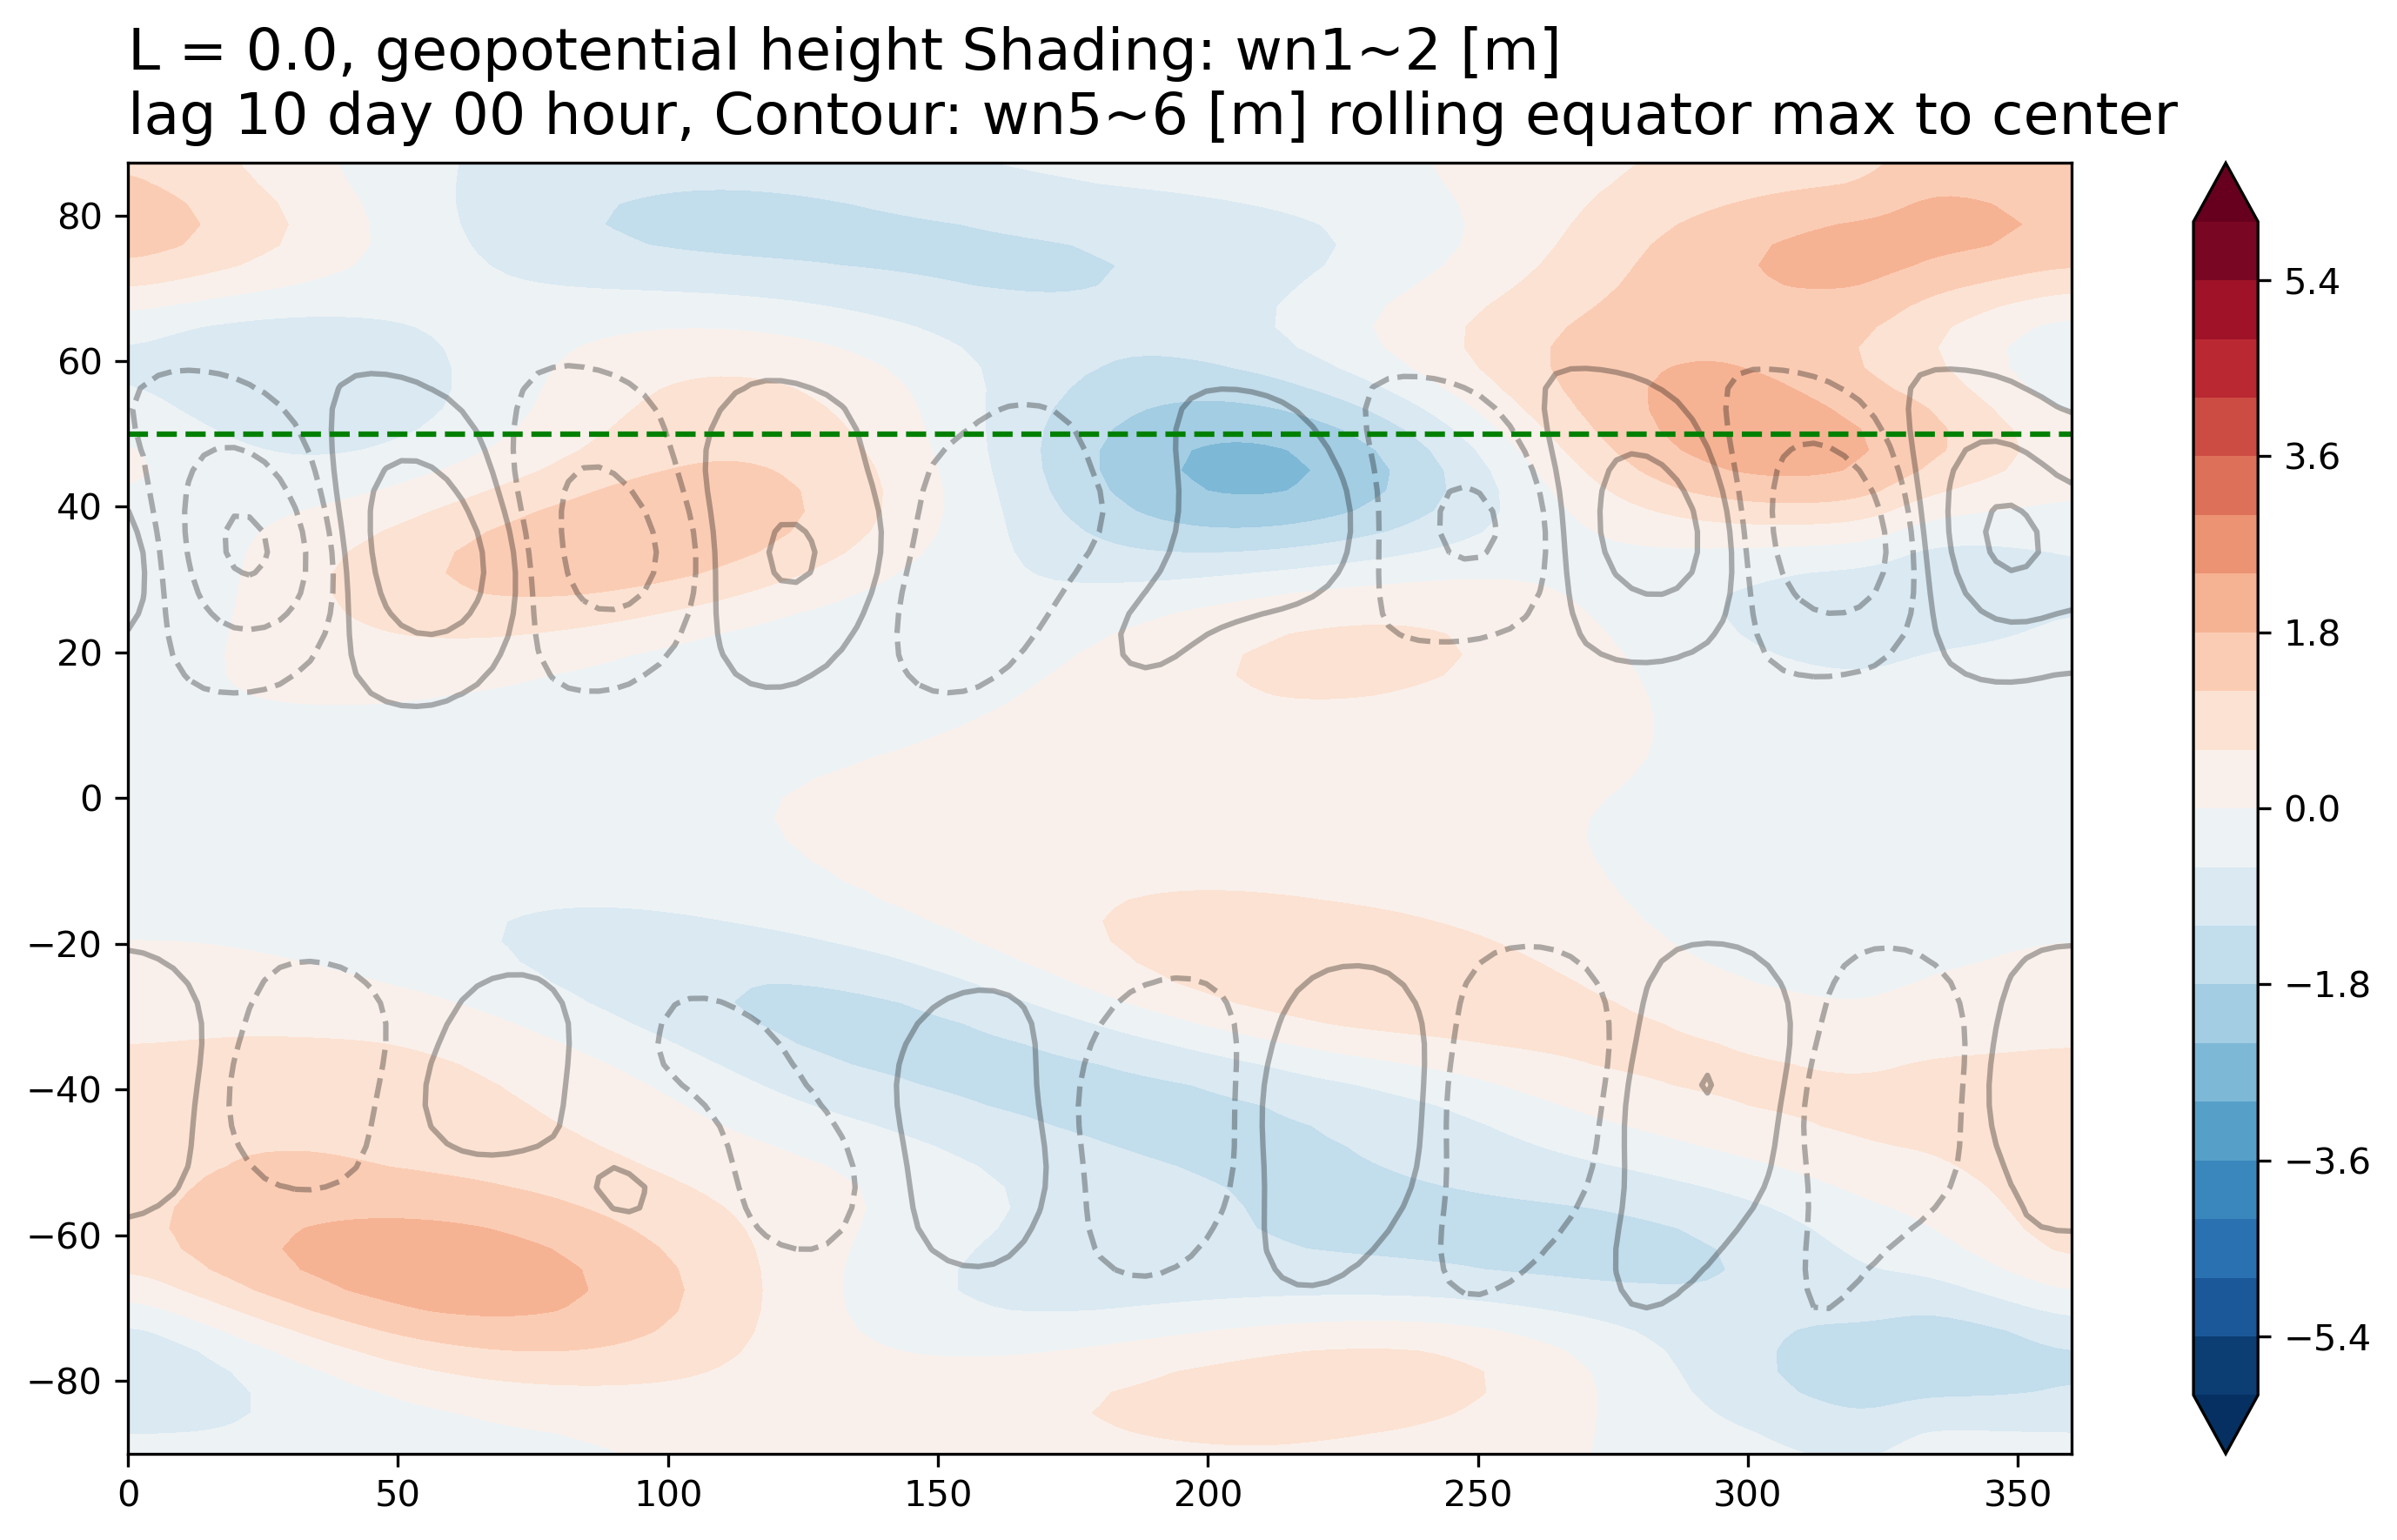

In [296]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Assume final, posi_x are defined, and final_roll has been correctly rolled as described

# Step 1: Wrap the data along the x-axis to create continuity
final_roll_wrapped         = np.hstack([final_roll, final_roll[:, :1]])  # Append first column to the end
final_contour_roll_wrapped = np.hstack([final_contour_roll, final_contour_roll[:, :1]])  # Append first column to the end


# Step 2: Extend x-axis for wrapped data
x = np.linspace(0, 360, 129, endpoint=True)  # Add one more point to represent the wrap-around
y = np.linspace(-90, 90, 64, endpoint=False)
xx, yy = np.meshgrid(x, y)

# Step 3: Optionally smooth the data
final_roll_smoothed         = gaussian_filter(final_roll_wrapped, sigma=2)
final_contour_roll_smoothed = gaussian_filter(final_contour_roll_wrapped, sigma=2)


# Step 4: Plot with extended data for boundary continuity
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
CS = plt.contourf(xx, yy, final_roll_smoothed, cmap="RdBu_r", levels=np.linspace(-6, 6, 21), extend="both")
plt.contour(xx,yy, final_contour_roll_smoothed, colors="Black", levels=np.linspace(0.3,5,5), alpha = 0.3)
plt.contour(xx,yy, final_contour_roll_smoothed, colors="Black", linestyles='--', levels=np.linspace(-5,-0.3,5),  alpha = 0.3)

# Additional plot elements as before
plt.hlines(y=50, xmin=0, xmax=360, colors="Green", linestyle="--", label="Annular mode center")
plt.colorbar(CS)
day = lag // 4
hour = (lag % 4) * 6
ax.set_title(f"L = {PR*0.01}, geopotential height Shading: wn1~2 [m]\nlag {day} day {hour:02d} hour, Contour: wn5~6 [m] rolling equator max to center", pad=8, fontsize=16, loc="left")
plt.tight_layout()
plt.show()


In [13]:
final.min()

-2.002105236062802

In [293]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import copy

# Assuming `prec_recon`, `z`, `prec_wn1`, `z_wn5_6`, and `z_wn1_2` are already defined
# Directory to save the images (if you need)
# save_dir = "/path/to/save/images/"

lags_range = range(2 * 4, 10 * 4 + 1)  # Lags from 5 to 10 days (5 * 4 to 10 * 4 in 6-hour intervals)
final_roll_smoothed_all = np.zeros((64,129))
final_contour_roll_smoothed_all = np.zeros((64,129))
aa = 0
for lag in lags_range:
    print(f"Now running {lag}")
    # Step 1: Initialize the required tmp arrays for each lag
    tmp              = prec_recon.mean(axis=1)[:, :]
    tmp_z            = copy.deepcopy(z[:, :, :].reshape([78000 * 64, 128]))
    tmp_prec_wn1     = copy.deepcopy(prec_wn1[:, :, :].reshape([78000 * 64, 128]))
    tmp_z_wn5_6      = copy.deepcopy(z_wn5_6[:, :, :].reshape([78000 * 64, 128]))
    tmp_z_wn1_2      = copy.deepcopy(z_wn1_2[:, :, :].reshape([78000 * 64, 128]))

    # Step 2: Calculate the position of the maximum in `tmp` for each row (longitude shift reference)
    posi_time, posi_x = np.where(tmp == np.max(tmp, axis=1)[:, np.newaxis])

    # Step 3: Roll the data for each lag
    for i in range(tmp.shape[0]):
        if i >= (78000 - lag):
            continue
        shift = 64 - posi_x[i]  # Calculate shift to align the maximum
        tmp[(i + lag), :]                              = np.roll(tmp[(i + lag), :], shift)
        tmp_z[(i + lag) * 64:((i + lag) + 1) * 64, :]  = np.roll(tmp_z[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_prec_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :] = np.roll(tmp_prec_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_z_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :]  = np.roll(tmp_z_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_z_wn5_6[(i + lag) * 64:((i + lag) + 1) * 64, :]  = np.roll(tmp_z_wn5_6[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)

    # Step 4: Reshape the arrays back to their original dimensions
    tmp_prec_wn1 = tmp_prec_wn1.reshape([78000, 64, 128])
    tmp_z_wn5_6  = tmp_z_wn5_6.reshape([78000, 64, 128])
    tmp_z_wn1_2  = tmp_z_wn1_2.reshape([78000, 64, 128])
    tmp_z        = tmp_z.reshape([78000, 64, 128])

    # # Calculate the composite for final and final_contour
    # lag_90 = 90 * 4
    # time_idx_positive_lag90 = time_idx_positive + lag_90
    # time_idx_positive_lag90 = time_idx_positive_lag90[time_idx_positive_lag90 < 78000]

    final = ((tmp_z_wn1_2[time_idx_positive, :, :].mean(axis=(0)) - tmp_z_wn1_2[time_idx_positive, :, :].mean(axis=(0, 2))[:, np.newaxis]))
    final_contour = ((tmp_z_wn5_6[time_idx_positive, :, :].mean(axis=(0)) - tmp_z_wn5_6[time_idx_positive, :, :].mean(axis=(0, 2))[:, np.newaxis]))

    # Step 5: Roll the equator max value to the center of longitude for final and final_contour
    final_roll         = copy.deepcopy(final[:, :])
    final_contour_roll = copy.deepcopy(final_contour[:, :])

    posi_time, posi_x         = np.where(final == np.max(final, axis=1)[:, np.newaxis])
    posi_time, posi_x_contour = np.where(final_contour == np.max(final_contour, axis=1)[:, np.newaxis])

    for i in range(final.shape[0]):
        final_roll[i, :]                              = np.roll(final[i, :], 64 - posi_x[32])
        final_contour_roll[i, :]                      = np.roll(final_contour[i, :], 64 - posi_x_contour[32])

    # Step 6: Prepare for wrapping and smoothing for continuity along x-axis
    final_roll_wrapped         = np.hstack([final_roll, final_roll[:, :1]])
    final_contour_roll_wrapped = np.hstack([final_contour_roll, final_contour_roll[:, :1]])

    # Step 7: Define the x and y coordinates and smooth the data for continuity
    x = np.linspace(0, 360, 129, endpoint=True)  # Add one more point to represent the wrap-around
    y = np.linspace(-90, 90, 64, endpoint=False)
    xx, yy = np.meshgrid(x, y)

    final_roll_smoothed         = gaussian_filter(final_roll_wrapped, sigma=2)
    final_contour_roll_smoothed = gaussian_filter(final_contour_roll_wrapped, sigma=2)

    final_roll_smoothed_all += final_roll_smoothed / len(lags_range)
    final_contour_roll_smoothed_all += final_contour_roll_smoothed / len(lags_range)
    aa += 1


Now running 8
Now running 9
Now running 10
Now running 11
Now running 12
Now running 13
Now running 14
Now running 15
Now running 16
Now running 17
Now running 18
Now running 19
Now running 20
Now running 21
Now running 22
Now running 23
Now running 24
Now running 25
Now running 26
Now running 27
Now running 28
Now running 29
Now running 30
Now running 31
Now running 32
Now running 33
Now running 34
Now running 35
Now running 36
Now running 37
Now running 38
Now running 39
Now running 40


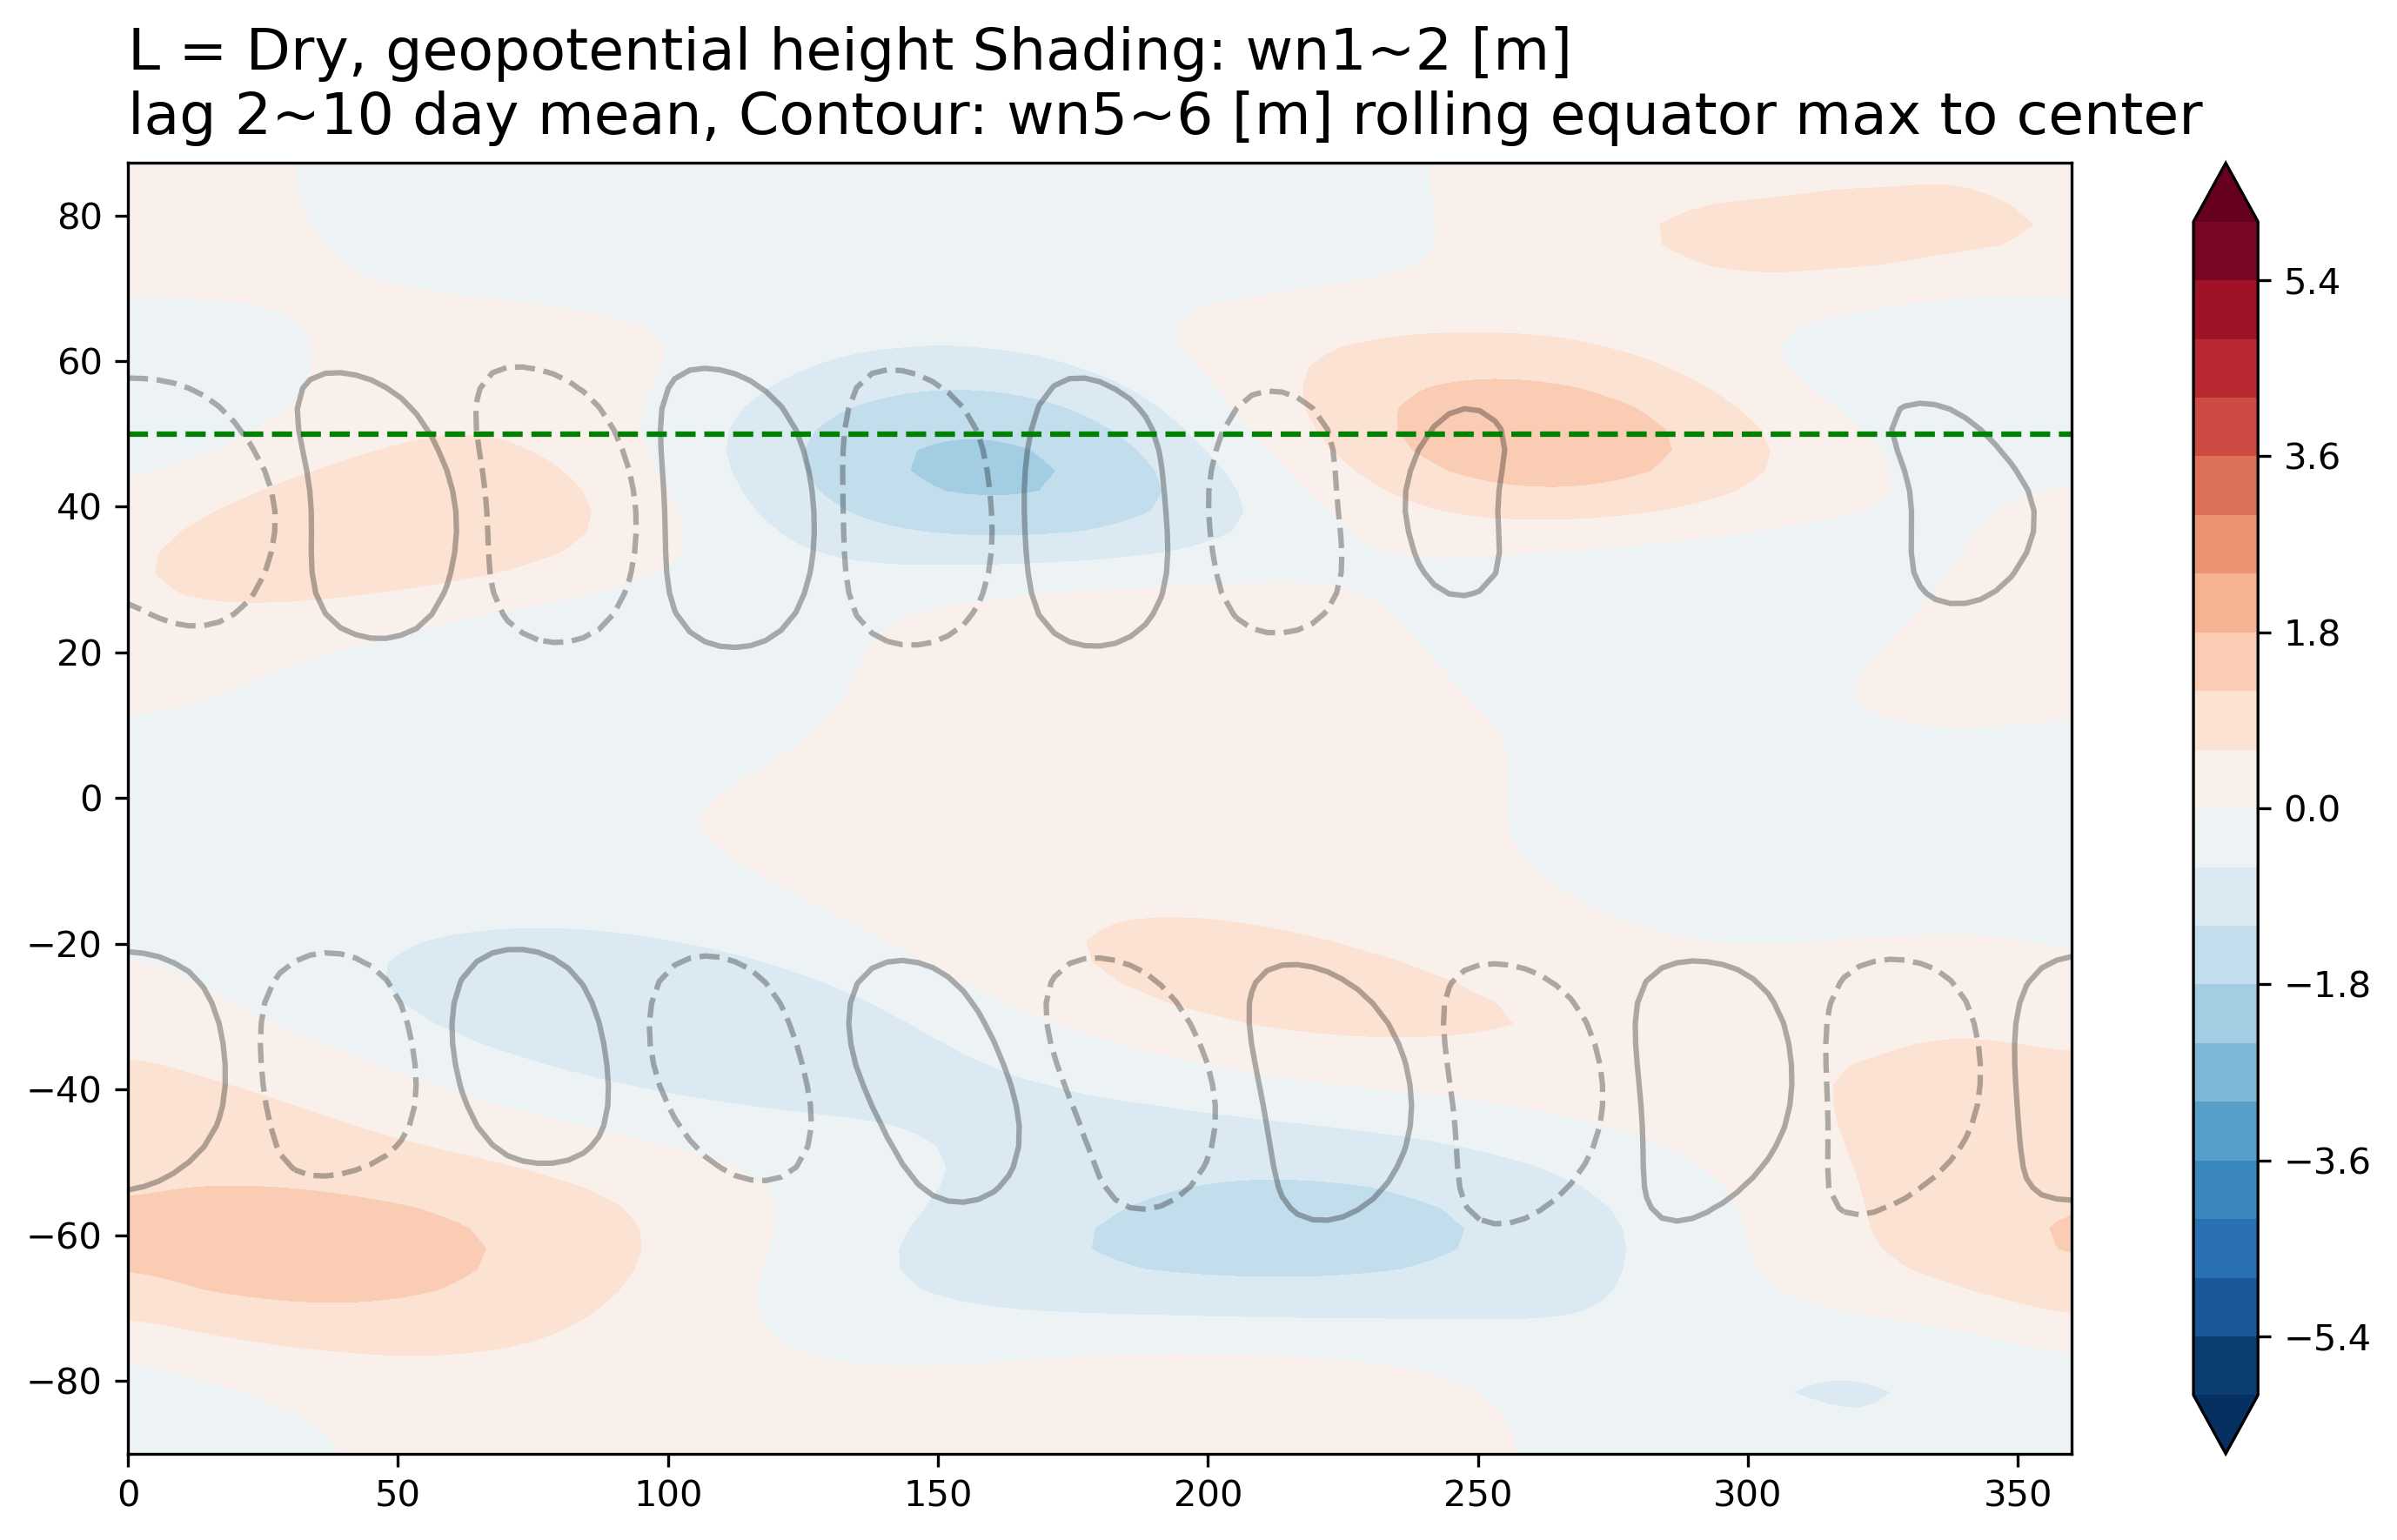

In [299]:
# Step 8: Plot each lag's data
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
CS = plt.contourf(xx, yy, final_roll_smoothed_all, cmap="RdBu_r", levels=np.linspace(-6, 6, 21), extend="both")
plt.contour(xx, yy, final_contour_roll_smoothed_all, colors="Black", levels=np.linspace(0.3, 5, 5), alpha=0.3)
plt.contour(xx, yy, final_contour_roll_smoothed_all, colors="Black", linestyles='--', levels=np.linspace(-5, -0.3, 5), alpha=0.3)

# Additional plot elements
plt.hlines(y=50, xmin=0, xmax=360, colors="Green", linestyle="--", label="Annular mode center")
plt.colorbar(CS)
day = lag // 4
hour = (lag % 4) * 6
ax.set_title(f"L = Dry, geopotential height Shading: wn1~2 [m]\nlag 2~10 day mean, Contour: wn5~6 [m] rolling equator max to center", pad=8, fontsize=16, loc="left")
plt.tight_layout()

# Optionally save each plot
# plt.savefig(f"{save_dir}/composite_lag_{day}_day_{hour:02d}_hour.png", bbox_inches='tight', dpi=300)
plt.show()

In [14]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set up general settings
x = np.linspace(0, 360, 128)
y = np.linspace(-90, 90, 64)
xx, yy = np.meshgrid(x, y)
mpl.rcParams['axes.linewidth'] = 1.5
savepath = f"/data92/PeterChang/Figs-113-1Seminar/Gill_PR{PR}/"

# Define the range for the loop
for lag in range(0, 8 * 4 + 1):  # Goes from 0 to 8*4
# for lag in range(0, 2):  # Goes from 0 to 8*4

    # Reset and roll data based on current lag, deleting previous data
    tmp = prec_recon.mean(axis=1)[:,:]
    tmp_z = copy.deepcopy(z[:,:,:].reshape([78000 * 64, 128]))
    tmp_prec_wn1 = copy.deepcopy(prec_wn1[:,:,:].reshape([78000 * 64, 128]))
    tmp_z_wn1 = copy.deepcopy(z_wn1[:,:,:].reshape([78000 * 64, 128]))

    # Identify positions for rolling
    posi_time, posi_x = np.where(tmp == np.max(tmp, axis=1)[:, np.newaxis])
    
    for i in range(tmp.shape[0]):
        if i < (78000 - lag):
            tmp[(i + lag), :] = np.roll(tmp[(i + lag), :], 64 - posi_x[i])
            tmp_z[(i + lag) * 64:((i + lag) + 1) * 64, :] = np.roll(tmp_z[(i + lag) * 64:((i + lag) + 1) * 64, :], 64 - posi_x[i])
            tmp_prec_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :] = np.roll(tmp_prec_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :], 64 - posi_x[i])
            tmp_z_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :] = np.roll(tmp_z_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :], 64 - posi_x[i])

    # Reshape data after rolling
    tmp_prec_wn1 = tmp_prec_wn1.reshape([78000, 64, 128])
    tmp_z_wn1 = tmp_z_wn1.reshape([78000, 64, 128])
    tmp_z = tmp_z.reshape([78000, 64, 128])

    # Plot setup
    fig, ax = plt.subplots(1, figsize=(10, 6), dpi=300)
    # Calculate day and hour from lag
    day = lag // 4  # each lag represents 6 hours, so 4 lags make 1 day
    hour = (lag % 4) * 6  # the remainder gives the hour
    # Update the title to display day and hour
    ax.set_title(f"L = Dry,                       Shading: geopotential height [m]\nlag {day} day {hour:02d} hour        Contour: precipitation [mm/day]", pad=8, fontsize=16, loc="left")
    
    # Plot contour
    cs = ax.contourf(xx, yy, tmp_z_wn1.mean(axis=0) - tmp_z_wn1.mean(axis=(0, 2))[:, np.newaxis], cmap="RdBu_r", levels=np.linspace(-6, 6, 21), extend="both")
    ax.set_xlabel("Longitude", fontsize=16)
    ax.set_ylabel("Latitude", fontsize=16)

    # Additional contours
    lats = 27
    latn = 38
    contour = ax.contour(xx[lats:latn, :], yy[lats:latn, :], tmp_prec_wn1[:, lats:latn, :].mean(axis=0), colors="Black")

    # Colorbar and legend
    cb = plt.colorbar(cs)
    cb.set_label("[m]", labelpad=-50, y=1.1, rotation=0, fontsize=14)
    cb.set_ticks([-6, -4.5, -3, -1.5, 0, 1.5, 3, 4.5, 6])
    cb.ax.tick_params(labelsize=14)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(direction='out', length=6)
    plt.hlines(y=50, xmin=0, xmax=360, colors="Green", linestyle="--", label="Annular mode center")
    plt.legend()

    # Save plot for the current lag
    # plt.savefig(f"/data92/PeterChang/Figs-113-1Seminar/Gill_PR{PR}/lag_{lag}.png", bbox_inches='tight', dpi=300)
    plt.savefig(f"{savepath}{lag}.png", bbox_inches='tight', dpi=300)
    plt.close(fig)  # Close the figure to save memory

    # Explicitly delete large variables to free memory
    del tmp, tmp_z, tmp_prec_wn1, tmp_z_wn1


In [15]:
!cd $savepath && ffmpeg -r 5 -i %d.png -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -pix_fmt yuv420p 0.mp4 -y


ffmpeg version 7.0.1 Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 12.4.0 (conda-forge gcc 12.4.0-0)
  configuration: --prefix=/home/PeterChang/miniconda3/envs/ML22 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1722545971544/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1722545971544/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1722545971544/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1722545971544/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --disable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-gnutls --enable-libmp3lame --enable-libvpx --enable-libass --enable-pthreads --enable-vaapi --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libaom --enabl

# tan^(-1)[B/A] -> wn1: Acos(x) + Bsin(x), wn2: Ccos(x) + Dsin(x)

In [173]:
if 'z_wn1' in globals():
    del z_wn1
if 'prec_wn1' in globals():
    del prec_wn1
if 'vor_wn1' in globals():
    del vor_wn1

prec_wn1   = fft_filtering(prec,dim=2,wave_numbers=[1,2])
z_wn1      = fft_filtering(z,dim=2,wave_numbers=[1]) # wave number 1~2 for shading
z_wn2      = fft_filtering(z,dim=2,wave_numbers=[2]) # wave number 1~2 for shading


128
3
ijk
kij
128
3
ijk
kij
128
3
ijk
kij


In [213]:
import numpy as np

# Assuming `data` is your 3D array with shape (78000, 64, 128)

# Step 1: Initialize arrays for storing A, B, and arctan results
# These arrays will have the same shape as `data`
A = np.zeros((78000, 64)) #np.zeros_like(z_wn2, dtype=np.float64)
B = np.zeros((78000, 64)) #np.zeros_like(z_wn2, dtype=np.float64)
arctan_values = np.zeros_like(z_wn2, dtype=np.float64)

# Step 2: Perform FFT across (y, x) dimensions for each time point
for t in range(z_wn1.shape[0]):
    fft_result = np.fft.fft(z_wn2[t, :, :], axis=1)  # 2D FFT on (y, x) for each time point
    # print(fft_result.real.shape)
    # Extract A and B coefficients
    A[t, :] = fft_result.real[:,2]  # Real part as A
    B[t, :] = fft_result.imag[:,2]  # Imaginary part as B

# Step 3: Calculate arctan(B/A) for each frequency component
arctan_values = np.arctan2(B, A)  # Shape: (78000, 64, 128)

# If you want only the first harmonic (first frequency), you can access it as:
# first_harmonic_arctan = arctan_values[:, 1, 1]  # Or other specific indices as needed


0.46364760900080615

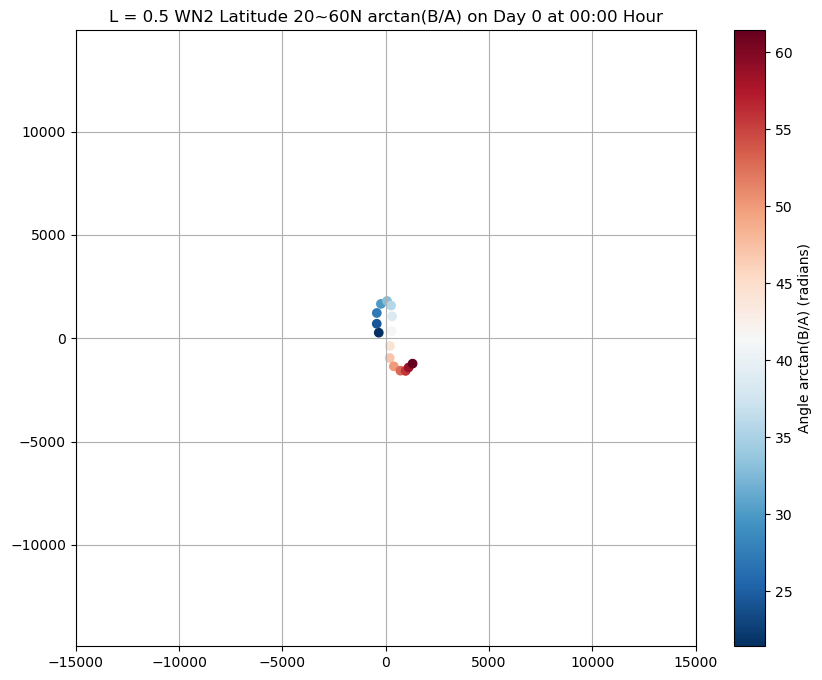

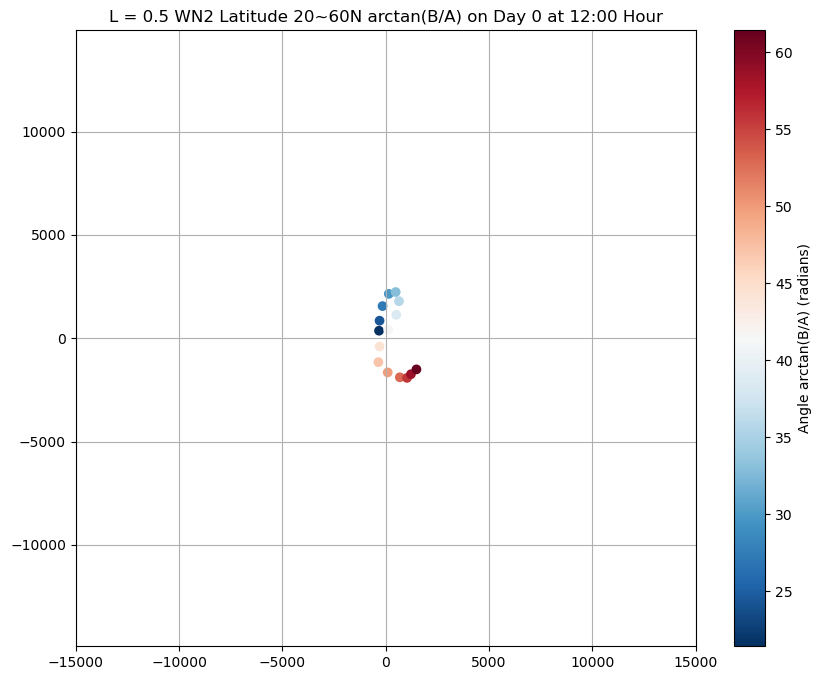

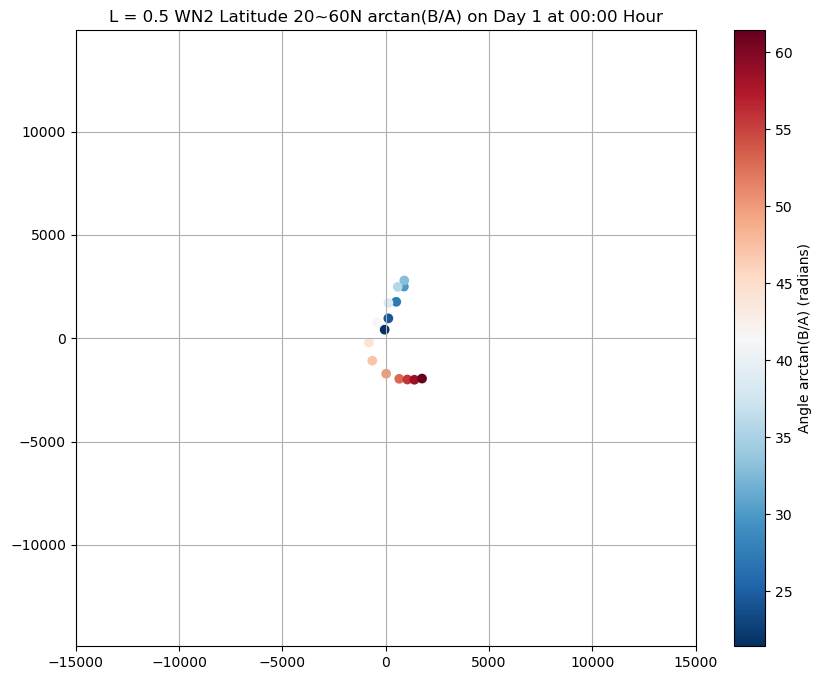

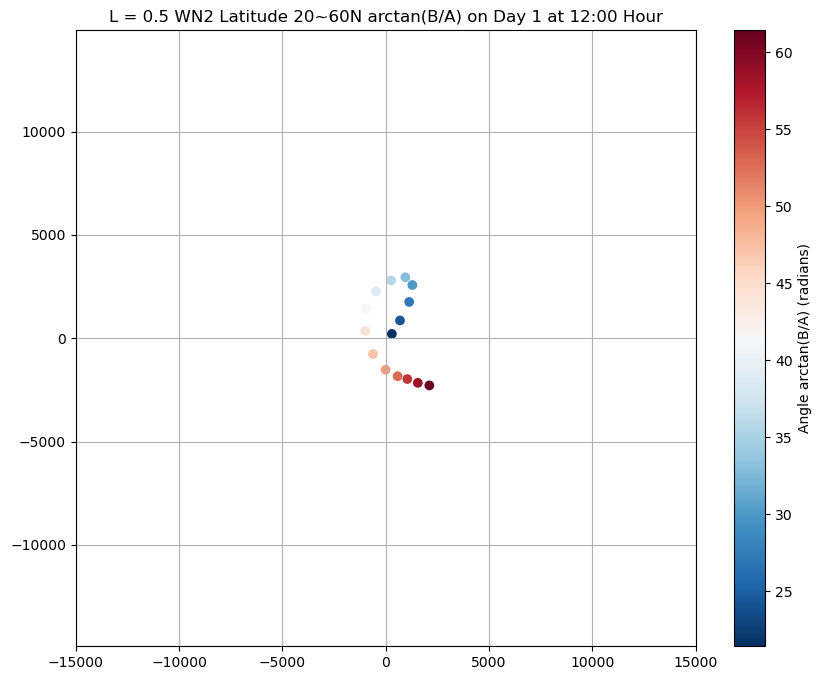

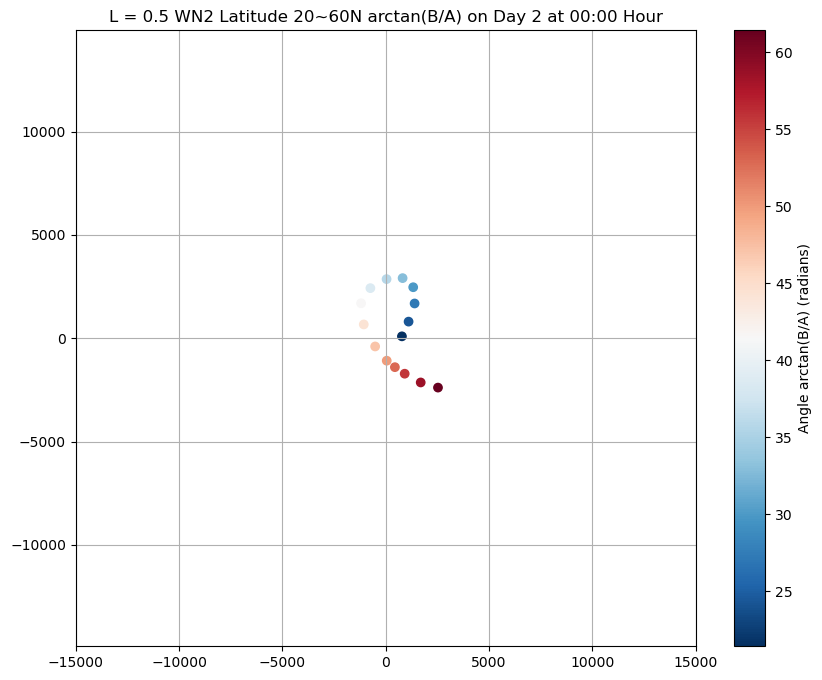

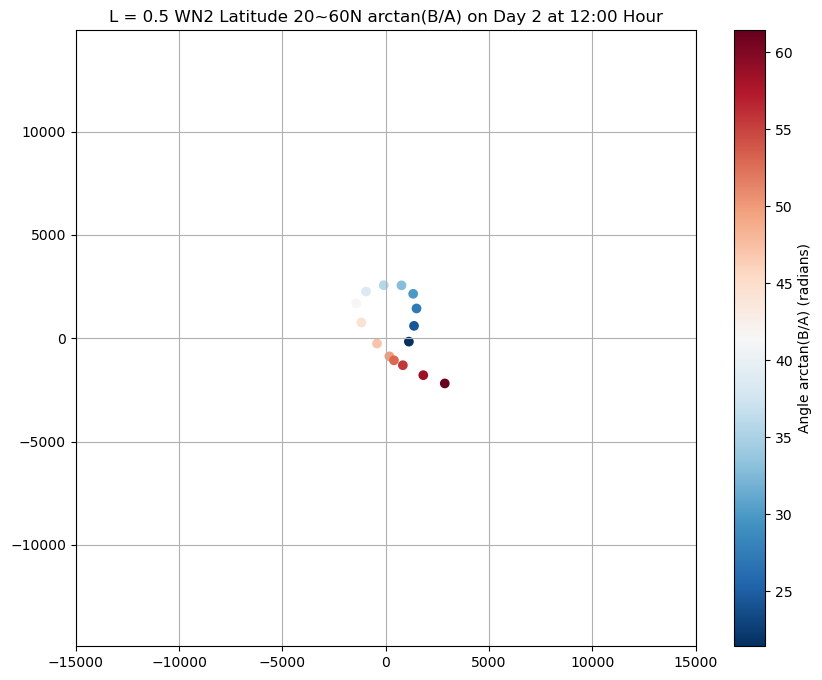

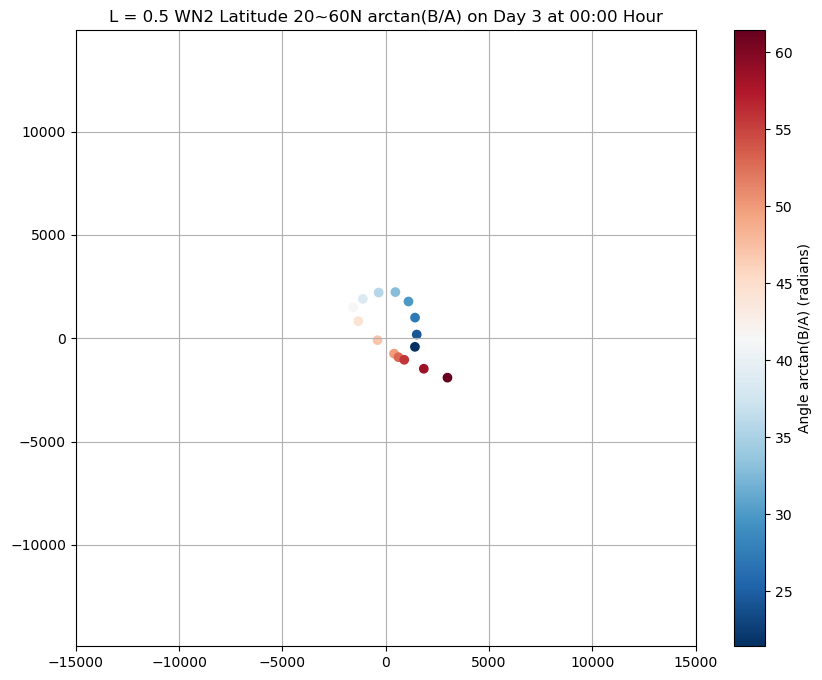

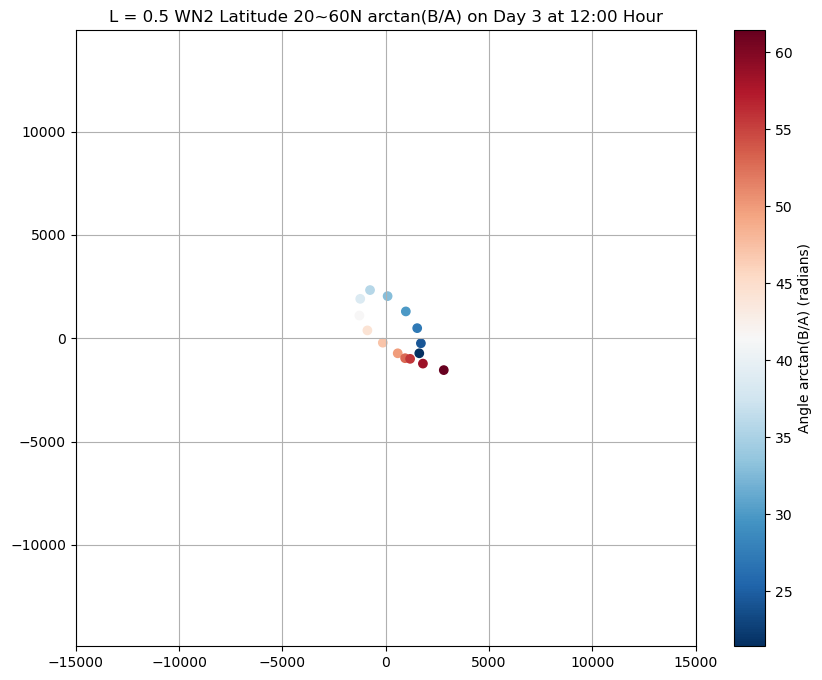

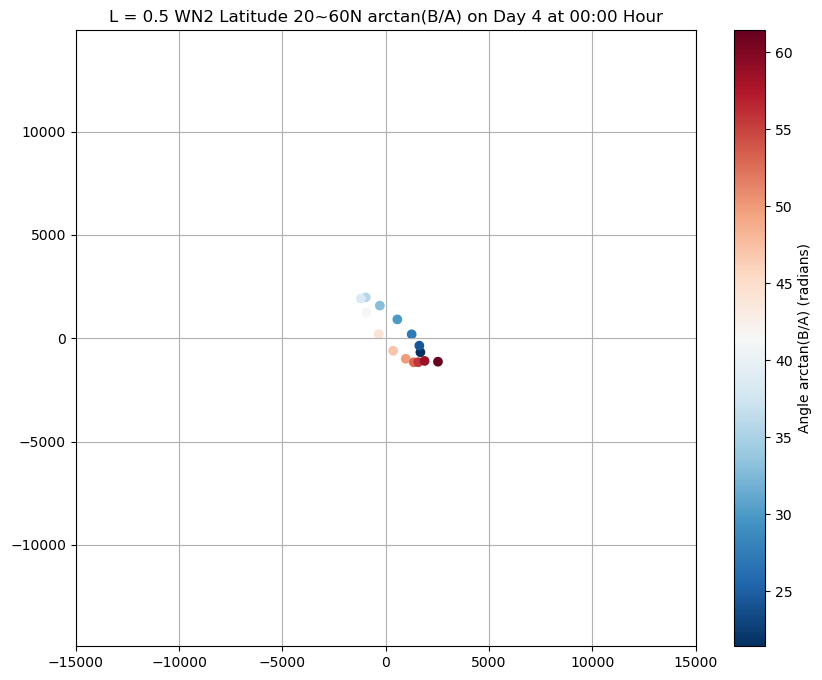

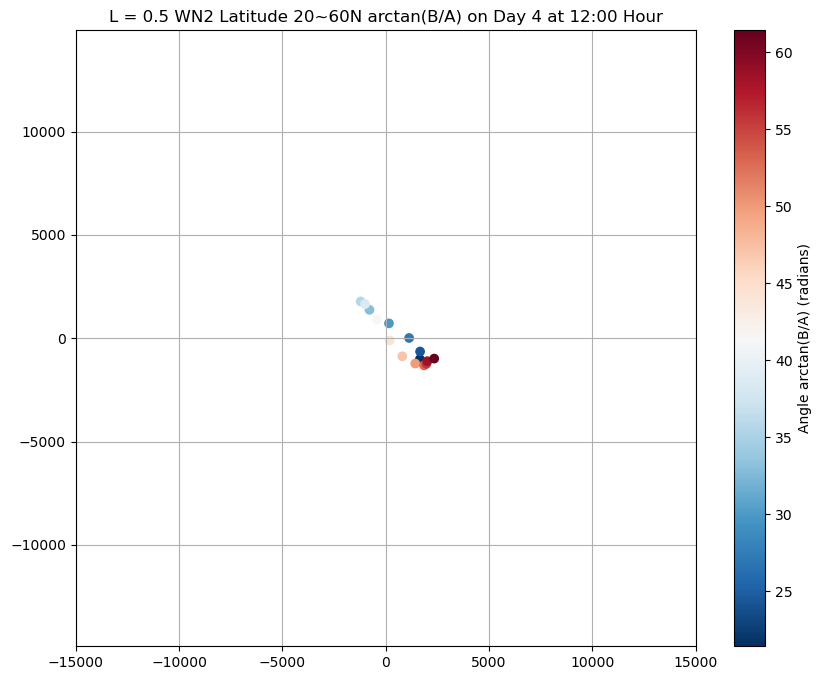

In [214]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming A, B, and arctan_values are already defined

# Directory to save the images
save_dir = f"/data92/PeterChang/test_arctan/PR{PR}"
aa = 0  # File naming index
lat = np.linspace(-90,90,64)
lat[39:-10]
# Loop over each time index
for time_idx in range(0, 20, 2):
    # Calculate the day and hour
    day = time_idx // 4
    hour = (time_idx % 4) * 6  # Gives 0, 6, 12, or 18

    # Select the specific slice for the current time index
    A_slice = A[time_idx, 39:-10] # 20~60N
    B_slice = B[time_idx, 39:-10]
    # arctan_slice = arctan_values[time_idx, 39:-10]
    
    # Create the scatter plot
    plt.figure(figsize=(10, 8), dpi=100)
    # sc = plt.scatter(A_slice, B_slice, c=arctan_slice, vmin=-3, vmax=3, cmap='RdBu_r', marker='o', alpha=1)
    sc = plt.scatter(A_slice, B_slice, c=lat[39:-10], cmap='RdBu_r', marker='o', alpha=1)
    

    # Customize the plot
    plt.colorbar(sc, label='Angle arctan(B/A) (radians)')
    # plt.xlabel('Cosine (A)')
    # plt.ylabel('Sine (B)')
    plt.title(f"L = 0.5 WN2 Latitude 20~60N arctan(B/A) on Day {day} at {hour:02d}:00 Hour")
    plt.grid()
    plt.axis('equal')
    plt.ylim([-15000, 15000])
    plt.xlim([-15000, 15000])
    
    # Save the plot
    # plt.savefig(f"{save_dir}/{aa}.png", bbox_inches='tight', dpi=300)
    # plt.close()  # Close the figure to free up memory
    aa += 1  # Increment the file index


In [630]:
print(save_dir)
!cd $save_dir && ffmpeg -r 5 -i %d.png -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -pix_fmt yuv420p arctan_result_WN2.mp4 -y


/data92/PeterChang/Figs-113-1Seminar/Gill_wn12_56_PR0/
/bin/bash: line 1: ffmpeg: command not found


array([21.42857143, 24.28571429, 27.14285714, 30.        , 32.85714286,
       35.71428571, 38.57142857, 41.42857143, 44.28571429, 47.14285714,
       50.        , 52.85714286, 55.71428571, 58.57142857, 61.42857143])

In [11]:
PR

50

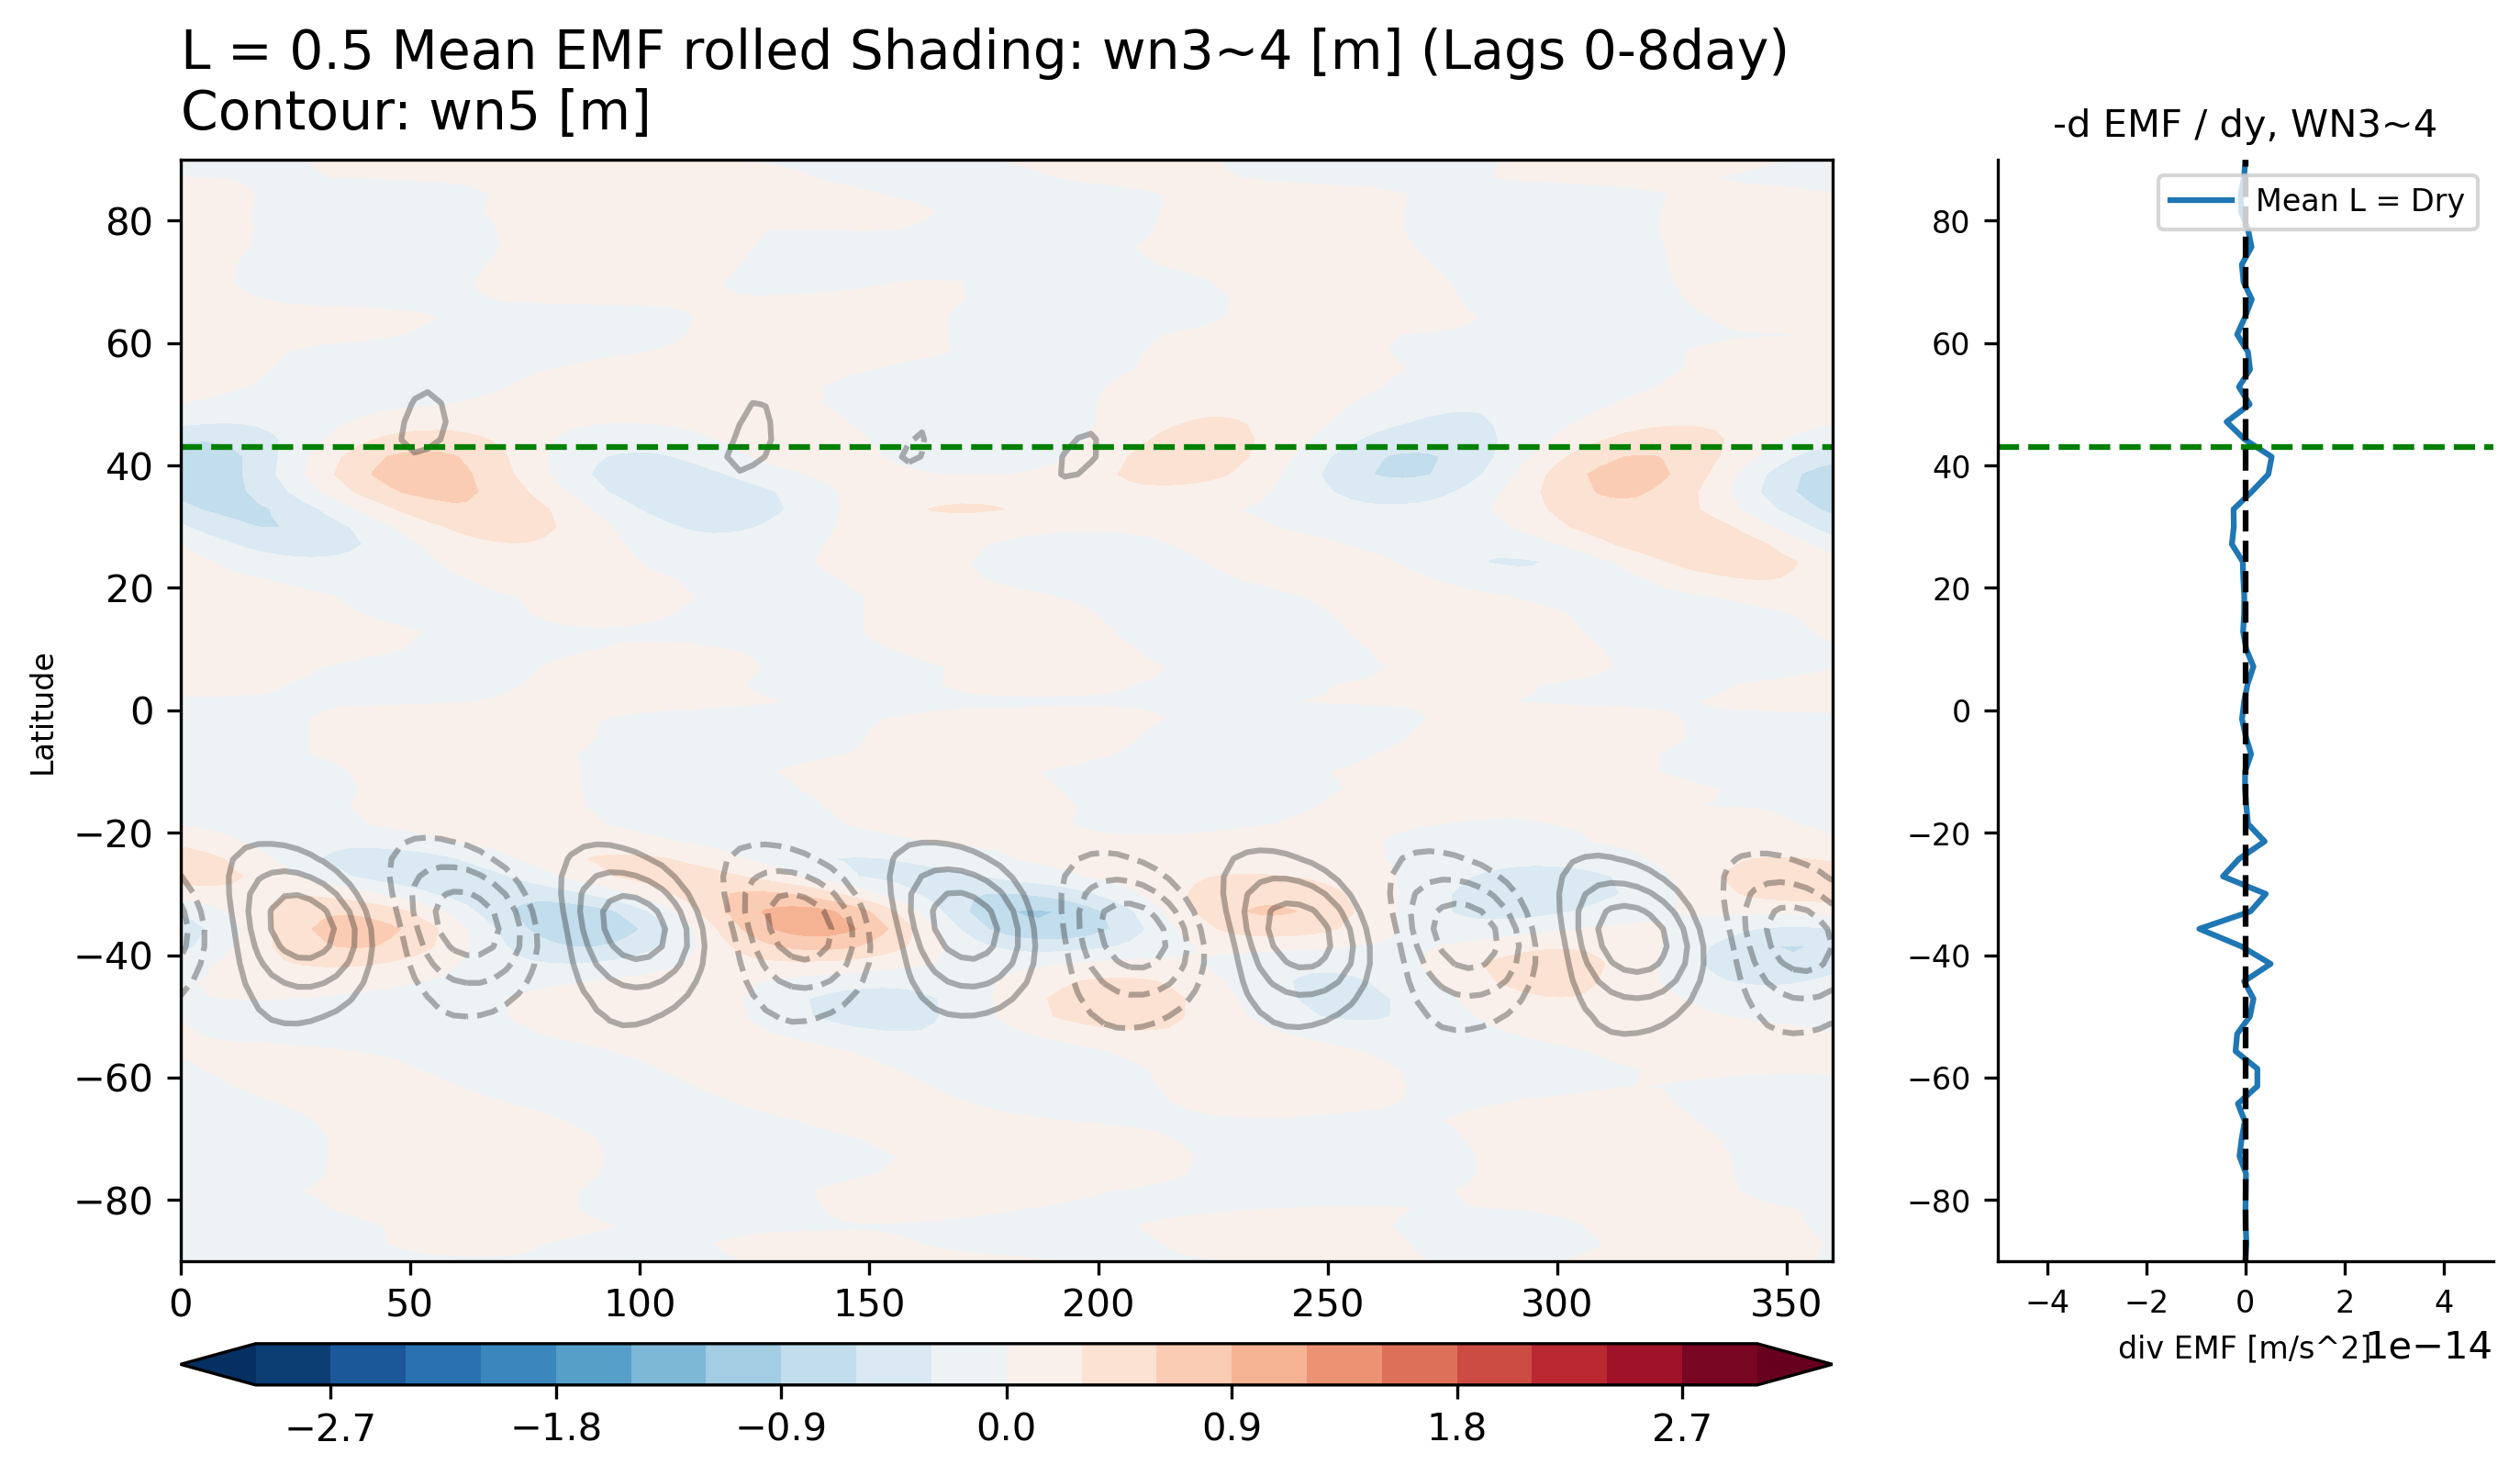

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import copy

# Assume all required data (`prec_recon`, `z`, `prec_wn1`, etc.) are already defined
y = np.linspace(-90, 90, 64)

# Define optional flags for saving and displaying plots
save_plots = False
show_plots = True
save_dir = "/data92/PeterChang/Figs-113-1Seminar/Gill_wn12_56_PR50/"

# Initialize arrays for accumulating results
final_sum = 0
final_EMF_sum = 0
final_contour_sum = 0
count = 0

for lag in range(0 * 4, 6 * 4 + 1):  # Lag range from 5*4 to 10*4
    # Reinitialize the temporary variables for each lag
    tmp              = prec_recon.mean(axis=1)[:, :]
    tmp_z            = copy.deepcopy(z[:, :, :].reshape([78000 * 64, 128]))
    tmp_prec_wn1     = copy.deepcopy(prec_wn1[:, :, :].reshape([78000 * 64, 128]))
    tmp_z_wn5_6      = copy.deepcopy(z_wn5_6[:, :, :].reshape([78000 * 64, 128]))
    tmp_z_wn1_2      = copy.deepcopy(z_wn1_2[:, :, :].reshape([78000 * 64, 128]))
    tmp_EMF_wn1_2    = copy.deepcopy(EMF_wn1_2[:, :, :].reshape([78000 * 64, 128]))

    # Adjust positions based on max values
    posi_time, posi_x = np.where(tmp == np.max(tmp, axis=1)[:, np.newaxis])
    for i in range(tmp.shape[0]):
        if i >= (78000 - lag):
            continue
        shift = 64 - posi_x[i]
        
        tmp[(i + lag), :]                              = np.roll(tmp[(i + lag), :], shift)
        tmp_z[(i + lag) * 64:((i + lag) + 1) * 64, :]  = np.roll(tmp_z[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_prec_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :] = np.roll(tmp_prec_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_z_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :]  = np.roll(tmp_z_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_EMF_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :] = np.roll(tmp_EMF_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_z_wn5_6[(i + lag) * 64:((i + lag) + 1) * 64, :]  = np.roll(tmp_z_wn5_6[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)

    # Reshape for accumulation
    tmp_prec_wn1 = tmp_prec_wn1.reshape([78000, 64, 128])
    tmp_z_wn5_6  = tmp_z_wn5_6.reshape([78000, 64, 128])
    tmp_z_wn1_2  = tmp_z_wn1_2.reshape([78000, 64, 128])
    tmp_EMF_wn1_2 = tmp_EMF_wn1_2.reshape([78000, 64, 128])
    tmp_z        = tmp_z.reshape([78000, 64, 128])

    # Accumulate results
    final_sum += (tmp_z_wn1_2.mean(axis=(0)) - tmp_z_wn1_2.mean(axis=(0, 2))[:, np.newaxis])
    final_EMF_sum += (tmp_EMF_wn1_2.mean(axis=(0)) - tmp_EMF_wn1_2.mean(axis=(0, 2))[:, np.newaxis])
    final_contour_sum += (tmp_z_wn5_6.mean(axis=(0)) - tmp_z_wn5_6.mean(axis=(0, 2))[:, np.newaxis])
    count += 1

# Calculate the mean across the lag range
final_mean = final_sum / count
final_EMF_mean = final_EMF_sum / count
final_contour_mean = final_contour_sum / count

# Prepare data for plotting
x = np.linspace(0, 360, 128)
y = np.linspace(-90, 90, 64)
xx, yy = np.meshgrid(x, y)

# Plotting the mean results
fig = plt.figure(figsize=(12, 5), dpi=300)
ax1 = fig.add_axes([0.05, 0.1, 0.5, 0.8])  # Adjust the size/position as needed

CS = ax1.contourf(xx, yy, final_EMF_mean, cmap="RdBu_r", levels=np.linspace(-3,3,21), extend="both")
ax1.contour(xx, yy, final_contour_mean, colors="Black", levels=np.linspace(0.2, 1, 5), alpha=0.3)
ax1.contour(xx, yy, final_contour_mean, colors="Black", linestyles='--', levels=np.linspace(-1, -0.2, 5), alpha=0.3)
ax1.hlines(y=43, xmin=0, xmax=360, colors="Green", linestyle="--", label="Annular mode center")

# Title and color bar
ax1.set_title("L = 0.5 Mean EMF rolled Shading: wn3~4 [m] (Lags 0-8day)\nContour: wn5 [m]", pad=8, fontsize=14, loc="left")
cax1 = fig.add_axes([0.05, 0.01, 0.5, 0.03])  # Place directly below ax1
cbar1 = plt.colorbar(CS, orientation="horizontal", cax=cax1)

# Add an inset line plot
ax2 = fig.add_axes([0.6, 0.1, 0.15, 0.8])  # Adjust the position and size of the line plot
dEMF_wn3_dy = np.zeros(64)
EMF_wn3_mean = np.mean(final_EMF_mean, axis=1)

for i in range(1, 64 - 1):
    dEMF_wn3_dy[i] = -(EMF_wn3_mean[i + 1] - EMF_wn3_mean[i - 1]) / (np.deg2rad(y[i + 1]) - np.deg2rad(y[i - 1]))

# Customize the inset plot
ax2.plot(dEMF_wn3_dy, y, label="Mean L = Dry")
ax2.hlines(y=43, xmin=-5E-14, xmax=5E-14, colors="Green", linestyle="--")
ax2.vlines(x=0, ymin=-90, ymax=90, colors="Black", linestyle="--")
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.set_xlabel("div EMF [m/s^2]", fontsize=8)
ax1.set_ylabel("Latitude", fontsize=8)
ax2.tick_params(axis='both', labelsize=8)
ax2.set_title("-d EMF / dy, WN3~4", fontsize=10)
ax2.legend(fontsize=8)
ax2.set_ylim([-90,90])
ax2.set_xlim([-5E-14,5E-14])

# Saving and displaying the plot based on the flags
if save_plots:
    plt.savefig(f"{save_dir}mean_lag_5_to_10.png", bbox_inches='tight', dpi=300)
if show_plots:
    plt.show()
else:
    plt.close(fig)  # Close to free memory if not displaying


# 1115 After Lorenz back

In [1283]:
# Select time index
def Cal_EOF_PC_for_barotropic(input_data):
    from EOF import EOF
    # input : (time, y)
    
    # Perform latitude weighting
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[1]))))

    # Initialize an EOF instance with weighted input data
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    print("n_component:", n_component)
    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="1D")
    
    # Compute EOFs and PCs
    eof_instance.get()
    
    # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]

    # Normalize PCs and EOFs
    PC1_norm, PC2_norm = PC1 / PC1.std(), PC2 / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
    return EOF1_norm, PC1_norm, EOF2_norm, PC2_norm

In [1340]:

file_path = f"/data92/PeterChang/1014_preprocessing/PR{PR}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"        
with h5py.File(file_path, 'r') as U_file:
    print(U_file.keys())
    u_forEOF = U_file["u"][:, :]  # Barotropic u
# u_daily = np.mean(u.reshape(-1,4,64), axis=1)
# print(u_daily.shape)

EOF1, PC1, EOF2, PC2 = Cal_EOF_PC_for_barotropic(u_forEOF[:,32:])

time_idx_positive = np.where(PC1 > 1 * PC1.std())[0]
time_idx_negative = np.where(PC1 < -1 * PC1.std())[0]
print(time_idx_positive.shape)

<KeysViewHDF5 ['u']>
n_component: 32
(12748,)


In [1341]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import copy

# Assume all required data (`prec_recon`, `z`, `prec_wn1`, etc.) are already defined
y = np.linspace(-90, 90, 64)

# Define optional flags for saving and displaying plots
save_plots =  False
show_plots =  True #False
save_dir = f"/data92/PeterChang/Figs-113-1Seminar/Gill_wn12_56_PR{PR}/"

variables_to_delete = ['tmp', 'tmp_z', 'tmp_prec_wn1', 'tmp_z_wn1', 'tmp_EMF_wn1', 'tmp_uD_wn1_2', 'tmp_v_vor_wn1_2']
for variable in variables_to_delete:
    if variable in globals():
        del globals()[variable]

# Initialize required variables
tmp              = prec_recon.mean(axis=1)[:, :]
tmp_z            = copy.deepcopy(z[:, :, :].reshape([78000 * 64, 128]))
tmp_prec_wn1     = copy.deepcopy(prec_wn1[:, :, :].reshape([78000 * 64, 128]))
tmp_z_wn5_6      = copy.deepcopy(z_wn5_6[:, :, :].reshape([78000 * 64, 128]))
tmp_z_wn1_2      = copy.deepcopy(z_wn1_2[:, :, :].reshape([78000 * 64, 128]))
tmp_EMF_wn1_2    = copy.deepcopy(EMF_wn1_2[:, :, :].reshape([78000 * 64, 128]))

tmp_uD_wn1_2    = copy.deepcopy(uD_wn1_2[:, :, :].reshape([78000 * 64, 128]))
tmp_v_vor_wn1_2    = copy.deepcopy(v_vor_wn1_2[:, :, :].reshape([78000 * 64, 128]))

# Position information for maximum points
posi_time, posi_x = np.where(tmp == np.max(tmp, axis=1)[:, np.newaxis])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_11121/1501399615.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


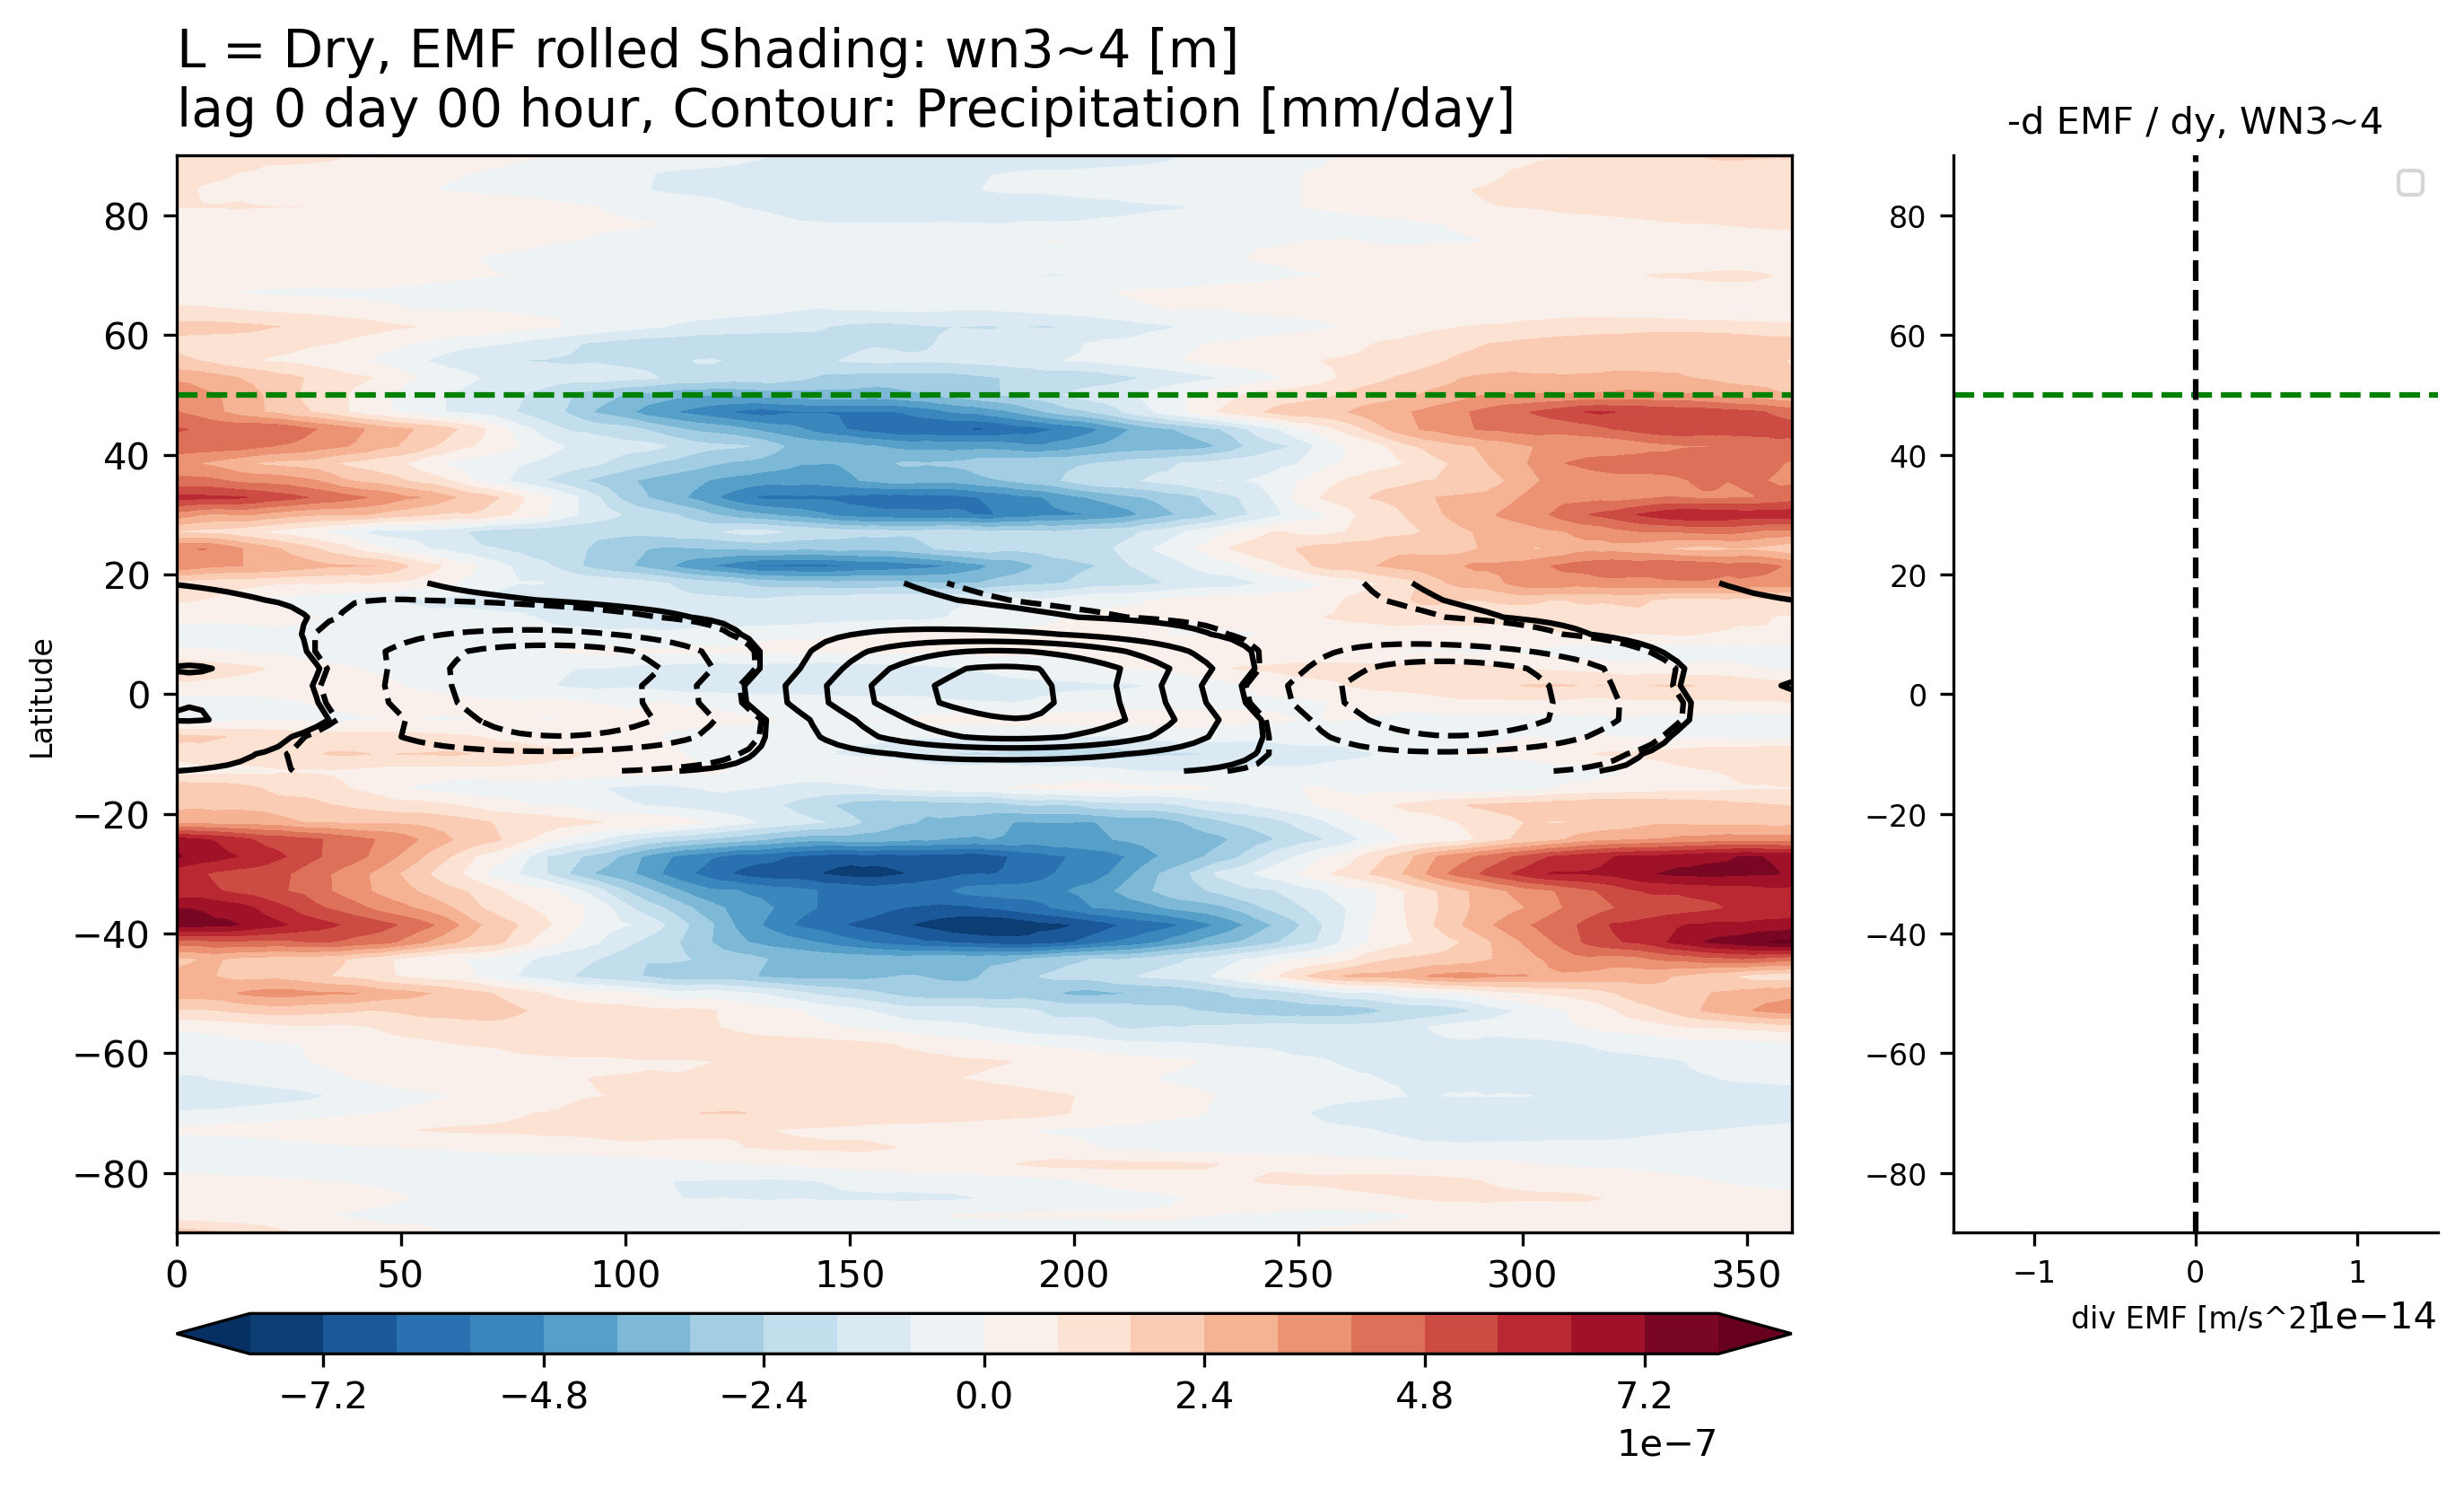

In [1343]:
# Process data for the specified lag
lags = 5 * 4
aa = 0
for lag in range(0 * 4, 0* 4 + 1):
    tmp              = prec_recon.mean(axis=1)[:, :]
    tmp_z            = copy.deepcopy(z[:, :, :].reshape([78000 * 64, 128]))
    tmp_prec_wn1     = copy.deepcopy(prec_wn1[:, :, :].reshape([78000 * 64, 128]))
    tmp_z_wn5_6      = copy.deepcopy(z_wn5_6[:, :, :].reshape([78000 * 64, 128]))
    tmp_z_wn1_2      = copy.deepcopy(z_wn1_2[:, :, :].reshape([78000 * 64, 128]))
    tmp_EMF_wn1_2    = copy.deepcopy(EMF_wn1_2[:, :, :].reshape([78000 * 64, 128]))

    tmp_uD_wn1_2    = copy.deepcopy(uD_wn1_2[:, :, :].reshape([78000 * 64, 128]))    
    tmp_v_vor_wn1_2    = copy.deepcopy(v_vor_wn1_2[:, :, :].reshape([78000 * 64, 128]))
    
    # Adjust positions based on max values
    posi_time, posi_x = np.where(tmp == np.max(tmp, axis=1)[:, np.newaxis])
    for i in range(tmp.shape[0]):
        if i >= (78000 - lag):
            continue
        shift = 64 - posi_x[i]
        
        tmp[(i + lag), :]                              = np.roll(tmp[(i + lag), :], shift)
        tmp_z[(i + lag) * 64:((i + lag) + 1) * 64, :]  = np.roll(tmp_z[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_prec_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :] = np.roll(tmp_prec_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_z_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :]  = np.roll(tmp_z_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_EMF_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :] = np.roll(tmp_EMF_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_z_wn5_6[(i + lag) * 64:((i + lag) + 1) * 64, :]  = np.roll(tmp_z_wn5_6[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)

        tmp_uD_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :]  = np.roll(tmp_uD_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        tmp_v_vor_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :]  = np.roll(tmp_v_vor_wn1_2[(i + lag) * 64:((i + lag) + 1) * 64, :], shift)
        
    # Reshape for plotting
    tmp_prec_wn1 = tmp_prec_wn1.reshape([78000, 64, 128])
    tmp_z_wn5_6  = tmp_z_wn5_6.reshape([78000, 64, 128])
    tmp_z_wn1_2  = tmp_z_wn1_2.reshape([78000, 64, 128])
    tmp_EMF_wn1_2 = tmp_EMF_wn1_2.reshape([78000, 64, 128])
    tmp_z        = tmp_z.reshape([78000, 64, 128])

    tmp_uD_wn1_2      = tmp_uD_wn1_2.reshape([78000, 64, 128])
    tmp_v_vor_wn1_2   = tmp_v_vor_wn1_2.reshape([78000, 64, 128])
    

    # Prepare data for main plot
    x = np.linspace(0, 360, 128)
    y = np.linspace(-90, 90, 64)
    xx, yy = np.meshgrid(x, y)
    final         = (tmp_z_wn1_2[:, :, :].mean(axis=(0)) - tmp_z_wn1_2[:, :, :].mean(axis=(0, 2))[:, np.newaxis])
    final_EMF     = (tmp_EMF_wn1_2[:, :, :].mean(axis=(0)) - tmp_EMF_wn1_2[:, :, :].mean(axis=(0, 2))[:, np.newaxis])
    final_contour = (tmp_z_wn5_6[:, :, :].mean(axis=(0)) - tmp_z_wn5_6[:, :, :].mean(axis=(0, 2))[:, np.newaxis])
    final_prec    = (tmp_prec_wn1[:, :, :].mean(axis=(0)) - tmp_prec_wn1[:, :, :].mean(axis=(0, 2))[:, np.newaxis])

    final_uD         = (tmp_uD_wn1_2[:, :, :].mean(axis=(0)) - tmp_uD_wn1_2[:, :, :].mean(axis=(0, 2))[:, np.newaxis])
    final_v_vor      = (tmp_v_vor_wn1_2[:, :, :].mean(axis=(0)) - tmp_v_vor_wn1_2[:, :, :].mean(axis=(0, 2))[:, np.newaxis])

    # Plotting the main figure
    # fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    fig = plt.figure(figsize=(12, 5), dpi=300)
    ax1 = fig.add_axes([0.05, 0.1, 0.5, 0.8])  # Adjust the size/position as needed
    
    CS = ax1.contourf(xx, yy, final_uD, cmap="RdBu_r", levels=21, extend="both")
    # ax1.contour(xx, yy, final_contour, colors="Black", levels=np.linspace(0.2, 1, 5), alpha=0.3)
    # ax1.contour(xx, yy, final_contour, colors="Black", linestyles='--', levels=np.linspace(-1, -0.2, 5), alpha=0.3)
    ax1.contour(xx[27:39], yy[27:39], final_prec[27:39], colors="Black", levels=np.linspace(0.0001, 0.04, 5))
    ax1.contour(xx[27:39], yy[27:39], final_prec[27:39], colors="Black", linestyles='--', levels=np.linspace(-0.04,-0.001, 5))
    
    ax1.hlines(y=50, xmin=0, xmax=360, colors="Green", linestyle="--", label="Annular mode center")

    # Calculate the day and hour for title
    day = lag // 4
    hour = (lag % 4) * 6
    ax1.set_title(f"L = Dry, EMF rolled Shading: wn3~4 [m]\nlag {day} day {hour:02d} hour, Contour: Precipitation [mm/day]", pad=8, fontsize=14, loc="left")
    cax1 = fig.add_axes([0.05, 0.01, 0.5, 0.03])  # Place directly below ax1
    cbar1 = plt.colorbar(CS, orientation="horizontal", pad=0.1, cax=cax1)
    
    # Add an inset line plot in a specific location within the main figure
    ax2 = fig.add_axes([0.6, 0.1, 0.15, 0.8])  # Adjust the position and size of the line plot
    # dEMF_wn3_dy = np.zeros(64)
    # EMF_wn3_mean = np.mean(final_EMF, axis=1)

    # for i in range(1, 64 - 1):
        # dEMF_wn3_dy[i] = -(EMF_wn3_mean[i + 1] - EMF_wn3_mean[i - 1]) / (np.deg2rad(y[i + 1]) - np.deg2rad(y[i - 1]))

    # Customize the inset plot
    # ax2.plot(dEMF_wn3_dy, y)
    ax2.hlines(y=50, xmin=-1.5E-14, xmax=1.5E-14, colors="Green", linestyle="--")
    ax2.vlines(x=0, ymin=-90, ymax=90, colors="Black", linestyle="--")
    ax2.spines["right"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax2.set_xlabel("div EMF [m/s^2]", fontsize=8)
    ax1.set_ylabel("Latitude", fontsize=8)
    ax2.tick_params(axis='both', labelsize=8)
    ax2.set_title("-d EMF / dy, WN3~4", fontsize=10)
    ax2.legend(fontsize=8)
    ax2.set_ylim([-90,90])
    ax2.set_xlim([-1.5E-14,1.5E-14])

    plt.tight_layout()
    # Saving and displaying the plot based on the flags
    if save_plots:
        plt.savefig(f"{save_dir}{aa}.png", bbox_inches='tight', dpi=300)
    if show_plots:
        plt.show()
    else:
        plt.close(fig)  # Close to free memory if not displaying

    aa += 1

In [1249]:
# import ffmpeg
!cd $save_dir && ffmpeg -r 5 -i %d.png -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -pix_fmt yuv420p result_0.mp4 -y


ffmpeg version 6.1.1 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 11.2.0 (Anaconda gcc)
  configuration: --prefix=/home/PeterChang/miniconda3 --cc=/croot/ffmpeg_1722024521393/_build_env/bin/x86_64-conda-linux-gnu-cc --ar=/croot/ffmpeg_1722024521393/_build_env/bin/x86_64-conda-linux-gnu-ar --nm=/croot/ffmpeg_1722024521393/_build_env/bin/x86_64-conda-linux-gnu-nm --ranlib=/croot/ffmpeg_1722024521393/_build_env/bin/x86_64-conda-linux-gnu-ranlib --strip=/croot/ffmpeg_1722024521393/_build_env/bin/x86_64-conda-linux-gnu-strip --disable-doc --enable-swresample --enable-swscale --enable-openssl --enable-libxml2 --enable-libtheora --enable-demuxer=dash --enable-postproc --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libdav1d --enable-zlib --enable-libaom --enable-pic --enable-shared --disable-static --disable-gpl --enable-version3 --disable-sdl2 --enable-libopenh264 --enable-libopus --enable-libmp3lame --enable-libopenjpeg -

In [1295]:
print(tmp_EMF_wn1_2.shape)
dfinal_EMF_dy = np.zeros(((78000, 64, 128)))
# EMF_wn3_mean = np.mean(final_EMF, axis=1)
for k in range(78000):
    for i in range(1, 64 - 1):
        dfinal_EMF_dy[k,i] =  -(tmp_EMF_wn1_2[k,i + 1] - tmp_EMF_wn1_2[k,i - 1]) / (np.deg2rad(y[i + 1]) - np.deg2rad(y[i - 1]))


(78000, 64, 128)


In [1296]:
EOF1.shape
print(dfinal_EMF_dy.shape)

(78000, 64, 128)


In [1297]:
EMF_wn1_2.max()

2127.561040904497

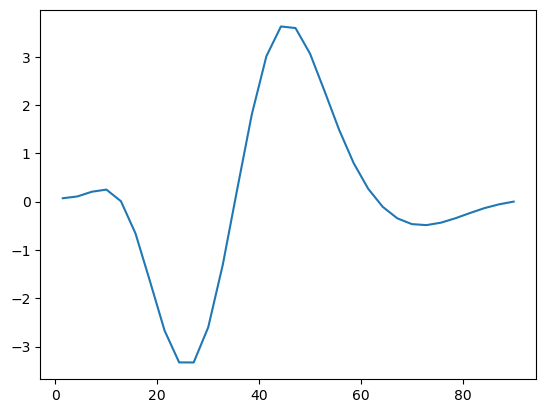

In [1298]:
plt.figure()
plt.plot(y[32:],EOF1)

In [1299]:
contribution = dfinal_EMF_dy[:,32:].mean(axis=2).dot(EOF1)

In [1300]:
# max_time_idx = np.argsort(np.max(contribution))
max_time_idx= np.unravel_index(np.argsort(contribution.ravel()),contribution.shape)

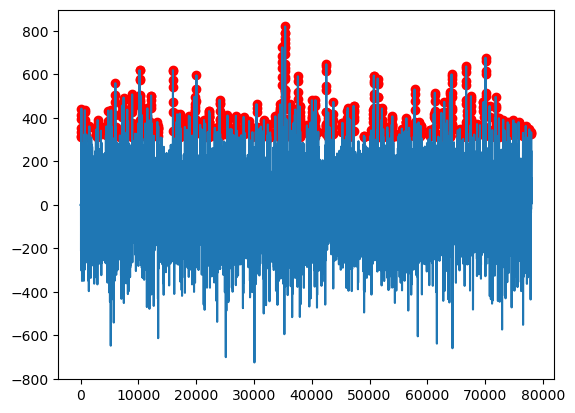

In [1310]:
plt.figure()
plt.plot(contribution)
plt.scatter(max_time_idx[0][-1000:], contribution[max_time_idx[0][-1000:]], color="Red") 

In [1302]:
max_time_idx[0][-50:]

array([64179, 50734,  6027, 51401, 50737, 66710, 37599, 15990, 10205,
       35389, 64182, 10208, 51402, 35390, 34916, 37600, 64181, 50736,
       50735, 20050, 64180, 70060, 66707, 42517, 70057, 35391, 15992,
       10207, 15991, 10206, 34912, 66708, 35401, 66709, 42519, 42518,
       35392, 34913, 70059, 70058, 34915, 35393, 35394, 34914, 35400,
       35395, 35396, 35397, 35399, 35398])

In [1311]:
test_final_EMF     = (dfinal_EMF_dy[max_time_idx[0][-10000:], :, :].mean(axis=(0)) - dfinal_EMF_dy[:, :, :].mean(axis=(0, 2))[:, np.newaxis])
test_final         = (tmp_z_wn1_2[max_time_idx[0][-10000:], :, :].mean(axis=(0)) - tmp_z_wn1_2[:, :, :].mean(axis=(0, 2))[:, np.newaxis])
test_final_prec    = (tmp_prec_wn1[max_time_idx[0][-10000:], :, :].mean(axis=(0)) - tmp_prec_wn1[:, :, :].mean(axis=(0, 2))[:, np.newaxis])


Text(0.5, 1.0, 'L = Dry and biggest 5000 time composite of -dEMF/dy.dot(EOF1)\nEMF WN3~4')

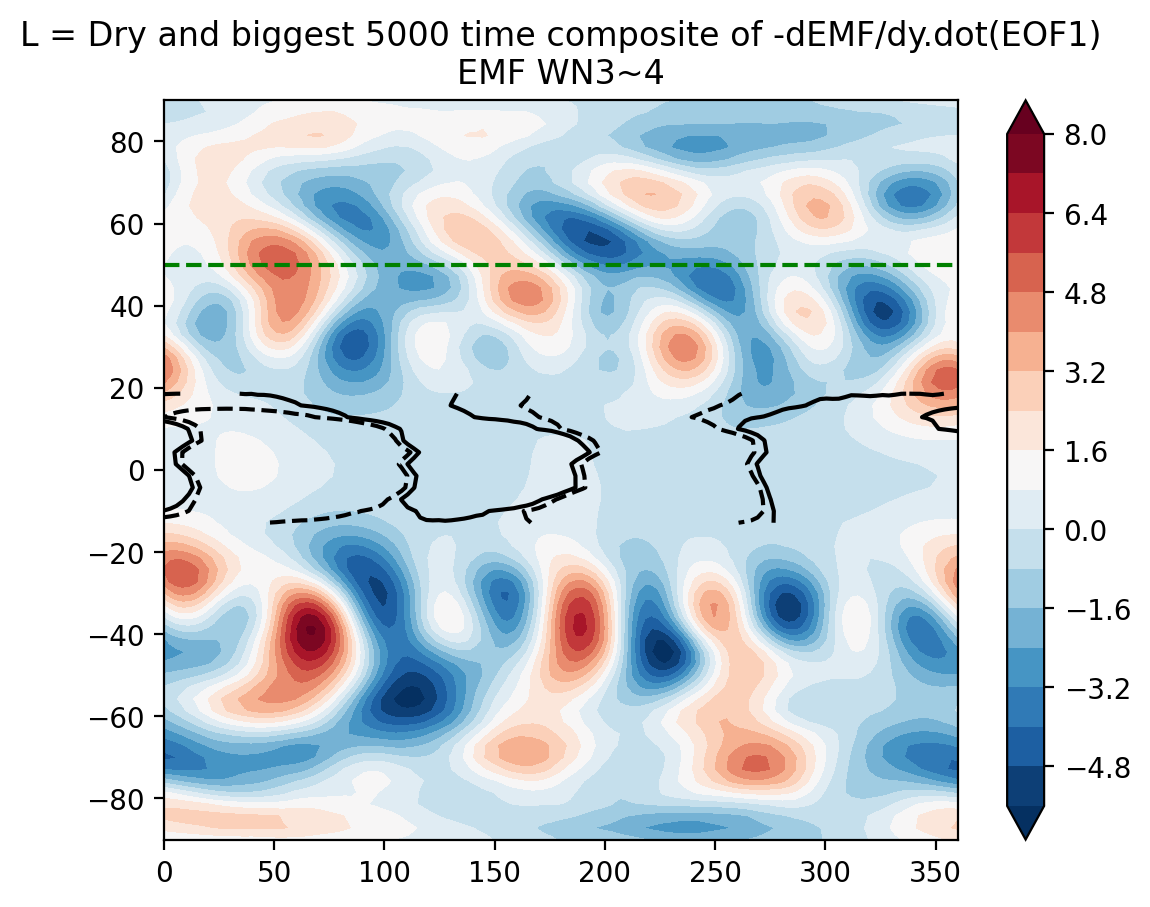

In [1316]:
plt.figure(dpi=200.)
CS = plt.contourf(xx[:,:], yy[:,:], test_final, cmap="RdBu_r", levels=21, extend="both")
plt.contour(xx[27:39], yy[27:39], test_final_prec[27:39], colors="Black", levels=np.linspace(0.001, 0.14, 5))
plt.contour(xx[27:39], yy[27:39], test_final_prec[27:39], colors="Black", linestyles='--', levels=np.linspace(-0.14, -0.001, 5))
plt.colorbar(CS)
plt.hlines(y=50, xmin=0, xmax=360, colors="Green", linestyle="--", label="Annular mode center")
plt.title("L = Dry and biggest 5000 time composite of -dEMF/dy.dot(EOF1)\nEMF WN3~4")

Text(0.5, 1.0, 'L = 0.5')

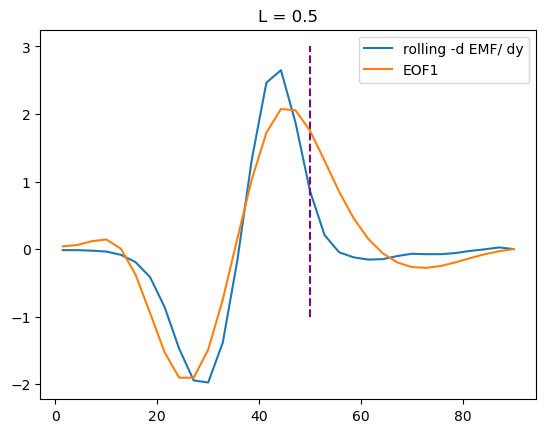

In [1314]:
plt.figure()
plt.plot(y[32:], test_final_EMF.mean(axis=1)[32:]/test_final_EMF.mean(axis=1)[32:].std(), label="rolling -d EMF/ dy")
plt.vlines(x=50, ymin=-1, ymax=3, colors="Purple", linestyle="--")
# plt.plot(y[32:], -EOF2/EOF2.std(), label="EOF2")
plt.plot(y[32:], EOF1/EOF1.std(), label="EOF1")
plt.legend()
plt.title("L = 0.5")

In [1230]:
final_prec.max()

0.38245924447721014

In [1231]:
final_prec.min()

-0.34873992452467145

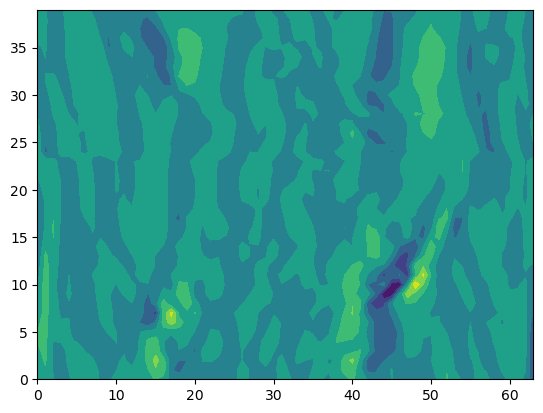

In [1236]:
EMF_prime_all = u * v
dEMF_dy = np.zeros(((78000, 64, 128)))
for k in range(78000):
    for i in range(1, 64-1):
        dEMF_dy[k,i,:] = -(EMF_prime_all[k, i+1] - EMF_prime_all[k, i-1]) / (np.deg2rad(y[i+1]) -  np.deg2rad(y[i-1]))

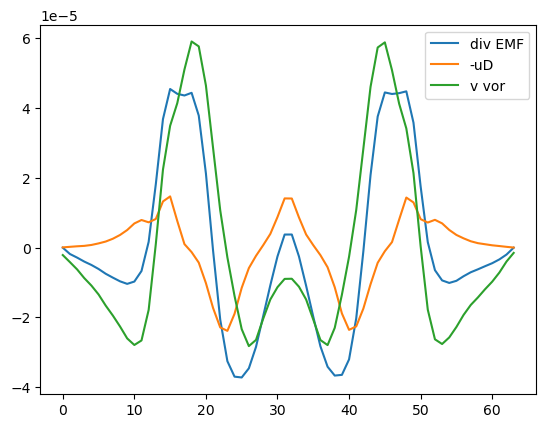

In [1274]:
neg_uD = -u*div
v_vor = v * vor

plt.figure()
plt.plot(dEMF_dy.mean(axis=(0,2))/ 6371E3, label="div EMF")
plt.plot(neg_uD.mean(axis=(0,2)), label="-uD")
plt.plot(v_vor.mean(axis=(0,2)), label="v vor")
plt.legend()


In [1291]:
final_prec.max()

0.043039140266975126

In [1317]:
EMF_test = u * v

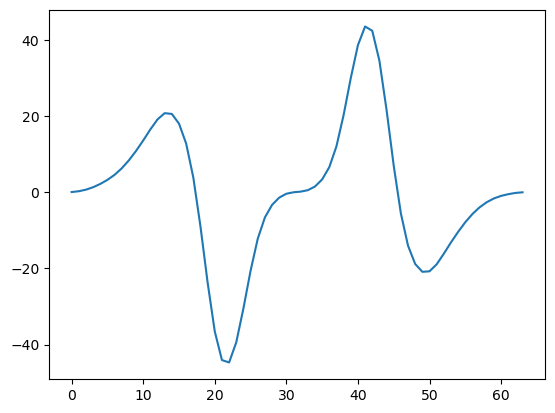

In [1319]:
plt.figure()
plt.plot(EMF_test.mean(axis=(0,2)))

# Back to master

In [236]:
# Select time index
def Cal_EOF_PC_for_barotropic(input_data):
    from EOF import EOF
    # input : (time, y)
    
    # Perform latitude weighting
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[1]))))

    # Initialize an EOF instance with weighted input data
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    print("n_component:", n_component)
    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="1D")
    
    # Compute EOFs and PCs
    eof_instance.get()
    
    # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]

    # Normalize PCs and EOFs
    PC1_norm, PC2_norm = PC1 / PC1.std(), PC2 / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
    return EOF1_norm, PC1_norm, EOF2_norm, PC2_norm

In [295]:
PR  = 0
file_path = f"/data92/PeterChang/1014_preprocessing/PR{PR}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"        
with h5py.File(file_path, 'r') as U_file:
    print(U_file.keys())
    u_forEOF = U_file["u"][:, :]  # Barotropic u
# u_daily = np.mean(u.reshape(-1,4,64), axis=1)
# print(u_daily.shape)

EOF1, PC1, EOF2, PC2 = Cal_EOF_PC_for_barotropic(u_forEOF[:,32:])

time_idx_positive = np.where(PC1 > 1 * PC1.std())[0]
time_idx_negative = np.where(PC1 < -1 * PC1.std())[0]
print(time_idx_positive.shape)

<KeysViewHDF5 ['u']>
n_component: 32
(12748,)


In [289]:
# load data
print(PR)
lat         = np.linspace(-90, 90, 64)
lat_cond    = np.where((lat>=-15)&(lat<=15))[0]
with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec.dat"
) as f:
        prec = f["prec"][:, :]
# prec -= prec.mean(axis=0)
prec *= 86400



# plt.figure()
# plt.contourf(tmp)

0


In [290]:
if 'z_wn1' in globals():
    del z_wn1
if 'prec_wn1' in globals():
    del prec_wn1
if 'vor_wn1' in globals():
    del vor_wn1

if 'EMF_wn1_2' in globals():
    del EMF_wn1_2

if 'uD_wn1_2' in globals():
    del uD_wn1_2
    
if 'v_vor_wn1_2' in globals():
    del v_vor_wn1_2


prec_wn1   = fft_filtering(prec,dim=2,wave_numbers=[1,2])

128
3
ijk
kij


In [384]:
def autocorr1(x,lags, spilt_to_chunk, window_length):
    if spilt_to_chunk == False:
        print("hihi")
        corr = np.zeros(int(lags))
        for l in range(lags):
            if l == 0:
                corr[l] = 1.
            else:
                corr[l] = np.corrcoef(x[l:],x[:-l])[0][1]
        return np.array(corr)
    if spilt_to_chunk == True:
        window_number = int(np.shape(x)[0] / window_length)
        if window_number * window_length != np.shape(x)[0]:
            x_window = np.zeros((window_number, window_length))
            #x_window[-1,-(np.shape(x)[0]- window_number * window_length):] = x[int(window_number * window_length):]
        else:
            x_window = np.zeros((window_number, window_length))
        for i in range(window_number):
            print(i)
            x_window[i,:] = x[i*window_length:(i+1)*window_length]


        corr = np.zeros((window_number , int(lags)))

        for i in range(window_number):
            for l in range(lags):
                if l == 0:
                    corr[i,l] = 1.
                else:
                    corr[i,l] = np.corrcoef(x_window[i,l:],x_window[i,:-l])[0][1]
        return np.array(corr).mean(axis=0)
    

In [385]:
auto_length = 100
window_length = 1000
spilt_to_chunk = False
auto_master  = autocorr1(PC1, auto_length, spilt_to_chunk, window_length) 

hihi


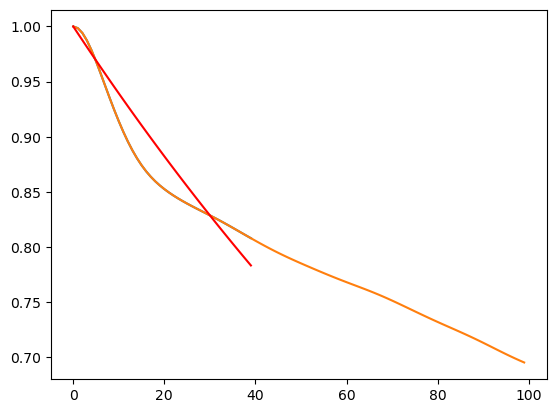

In [394]:
auto = np.zeros((40,))
for lag in range(40):
    auto[lag]=np.corrcoef(PC1[:78000-lag],PC1[lag:])[0][1]
plt.figure()
plt.plot(auto)
plt.plot(auto_master)
plt.plot([np.exp((np.log(auto[30]))*i/30) for i in range(0,40)],'r')

In [395]:
auto[1]

0.9984940113538416

In [396]:
12748*(1-auto[1])/(1+auto[1])

9.606405199193594

In [296]:
final = np.var(prec_wn1[:,27:37,:].mean(axis=1),axis=1)

final_lag_p = np.zeros((100,1))
final_lag_n = np.zeros((100,1))
for i in range(100):
    tmp            = time_idx_positive+4*i
    tmp            = tmp[tmp<78000] 
    final_lag_p[i]   = final[tmp].mean(axis=0)
    
    tmp            = time_idx_negative+4*i
    tmp            = tmp[tmp<78000]
    final_lag_n[i]   = final[tmp].mean(axis=0)

In [347]:
import random

# Generate a list of numbers from 1 to 100
nums = list(range(0, 78000))

boostrap_time = 500
random_nums = np.zeros(boostrap_time)
# Randomly choose 5 numbers from the list
for i in range(boostrap_time):
    random_nums[i] = final[random.sample(nums, 1245)].mean() 

# print("Randomly chosen numbers:", random_nums)
random_nums.mean()


0.1169638207025733

Text(0.5, 1.0, 'L = Dry z lead prec')

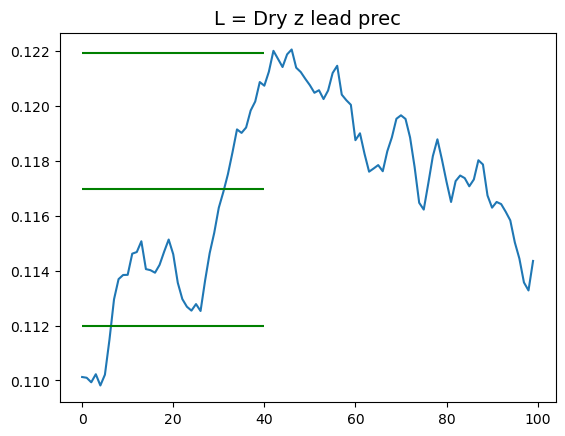

In [349]:
plt.figure()
plt.plot(final_lag_n )
plt.hlines(y = random_nums.mean(), xmin=0, xmax=40, color="Green")
plt.hlines(y = random_nums.mean() + 2* random_nums.std(), xmin=0, xmax=40, color="Green")
plt.hlines(y = random_nums.mean() - 2* random_nums.std(), xmin=0, xmax=40, color="Green")
plt.title("L = Dry z lead prec", fontsize=14)


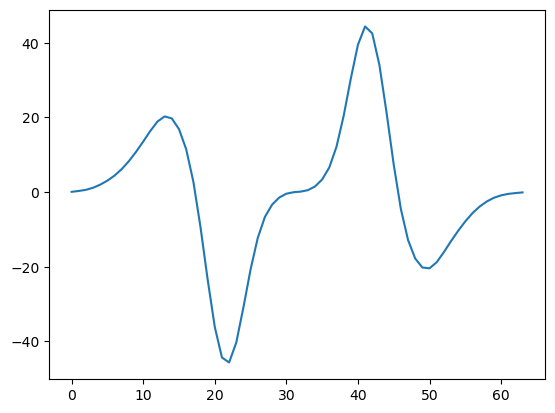

In [351]:
v = read_var_at_level(PR, "grid_v_c_xyzt", 500, 20000, level_index) 
v -= v.mean(axis=2)[:,:,np.newaxis]

u = read_var_at_level(PR, "grid_u_c_xyzt", 500, 20000, level_index) 
u -= u.mean(axis=2)[:,:,np.newaxis]
EMF = u * v
plt.figure()
plt.plot(EMF.mean(axis=(0,2)))

In [352]:
# EMF_wn3_mean = np.mean(EMF, axis=1)
dEMF_wn12_dy = np.zeros(((78000, 64, 128)))
for k in range(78000):
    for i in range(1, 64 - 1):
        dEMF_wn12_dy[k, i] = -(EMF[k, i + 1] - EMF[k, i - 1]) / (np.deg2rad(y[i + 1]) - np.deg2rad(y[i - 1]))

In [353]:
dEMF_wn12_dy.shape

(78000, 64, 128)

In [356]:
final_EMF = dEMF_wn12_dy.mean(axis=(2))[:,32:37].mean(axis=1)

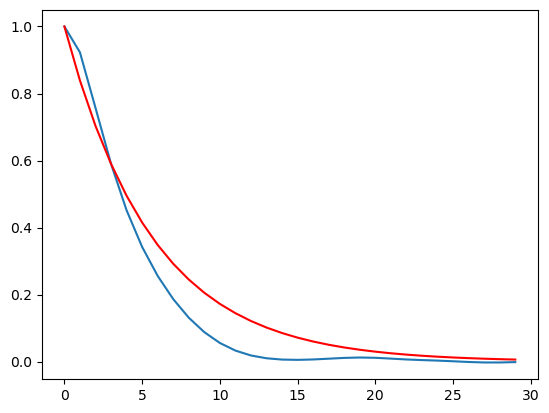

In [357]:
auto = np.zeros((30,))
for lag in range(30):
    auto[lag]=np.corrcoef(final_EMF[:78000-lag],final_EMF[lag:])[0][1]
plt.figure()
plt.plot(auto)
plt.plot([np.exp((np.log(auto[3]))*i/3) for i in range(0,30)],'r')

In [358]:
12748*(1-auto[1])/(1+auto[1])

511.9884378798011

In [359]:
import random

# Generate a list of numbers from 1 to 100
nums = list(range(0, 78000))

boostrap_time = 500
random_nums = np.zeros(boostrap_time)
# Randomly choose 5 numbers from the list
for i in range(boostrap_time):
    random_nums[i] = final_EMF[random.sample(nums, 511)].mean()-final_EMF[random.sample(nums, 511)].mean()

In [374]:
tropical_precip_wn12_p = np.where((final-final.mean()) /final.std() >2*final.std())[0]
tropical_precip_wn12_n = np.where((final-final.mean()) /final.std()<-2*final.std())[0]

final_lag_EMF_p        = np.zeros((60,1))
final_lag_EMF_n        = np.zeros((60,1))

for i in range(60):
    tmp            = tropical_precip_wn12_p+4*i
    tmp            = tmp[tmp<78000] 
    final_lag_EMF_p[i]   = final_EMF[tmp].mean(axis=0)
    
    tmp            = tropical_precip_wn12_n+4*i
    tmp            = tmp[tmp<78000] 
    final_lag_EMF_n[i]   = final_EMF[tmp].mean(axis=0)
    

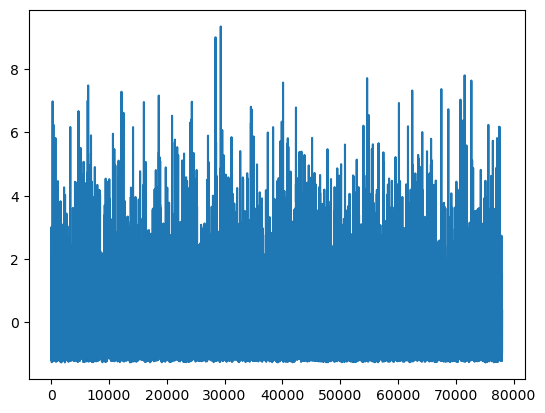

In [380]:
plt.figure()
plt.plot((final-final.mean()) /final.std())

Text(0.5, 1.0, 'L = Dry prec lead div m')

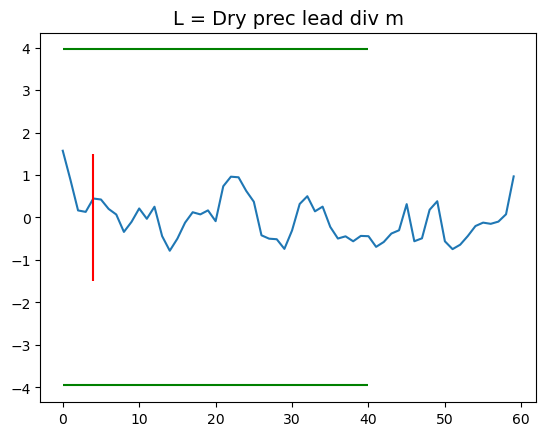

In [376]:
plt.figure()
plt.plot(final_lag_EMF_n - final_lag_EMF_p)
#plt.hist(final)
# plt.hlines(y = random_nums.mean(), xmin=0, xmax=40, color="Green")
plt.hlines(y = 2*random_nums.std(), xmin=0, xmax=40, color="Green")
plt.hlines(y = -2*random_nums.std(), xmin=0, xmax=40, color="Green")
plt.vlines(x = 4, ymin=-1.5, ymax=1.5, color="Red")
plt.title("L = Dry prec lead div m", fontsize=14)

